# 📊 **EDA: Graduados ESO**

## **Análisis de Habilidades TIC en España (INE, API 43698)**



🎓 Proyecto Académico: Brecha Digital Educativa

🏛️ **Fuente**: Instituto Nacional de Estadística (INE):

INE / INEbase — *Encuesta de Transición Educativa-Formativa e Inserción Laboral*  
**Catálogo**: <https://datos.gob.es/es/catalogo/ea0010587-graduados-en-eso-segun-sus-habilidades-tic-por-sexo-ccaa-de-estudio-y-tipo-de-centro-identificador-api-43698>  

Descargas directas: CSV ';' <https://www.ine.es/jaxi/files/tpx/csv_bdsc/43698.csv>

📅 Fecha: 2024

> Objetivo: limpiar y analizar el dataset de *Graduados en ESO según sus habilidades TIC* por **sexo**, **CCAA** y **tipo de centro**, y producir insight accionable para un público ejecutivo.




## **Qué vas a encontrar en este notebook**

- Gestión de CSV.
- Diccionario de datos y chequeos de calidad (duplicados, tipos, nulos).
- Limpieza (estandarización de nombres, tratamiento de `Total` y `No consta`).
- Estadística descriptiva (univariado/bivariado/multivariado).
- Detección de outliers y justificación.
- Visualizaciones con `pandas`, `matplotlib`, `seaborn` y `plotly`.
- Mapa coroplético por CCAA (base OpenStreetMap) con `folium` + `geopandas`.
- Hypothesis testing (chi-cuadrado, test de proporciones).
- Storytelling + **generación automática** de un *executive report* en `reports/executive_report.md`.



**CONTEXTO DEL PROYECTO:**
==========================
Este análisis exploratorio examina las habilidades TIC de graduados en ESO en España, analizando las diferencias por género, comunidad autónoma y tipo de centro educativo.

OBJETIVO:
- Identificar brechas digitales en educación
- Proporcionar insights para políticas educativas
- Analizar diferencias territoriales y de género
- Generar recomendaciones estratégicas

METODOLOGÍA:
1. Carga y exploración inicial de datos
2. Limpieza y preprocesamiento
3. Análisis exploratorio (univariado, bivariado, multivariado)
4. Pruebas de hipótesis estadísticas
5. Visualizaciones avanzadas
6. Storytelling y conclusiones


**1. IMPORTACIÓN DE LIBRERÍAS Y CONFIGURACIÓN INICIAL VISUALIZACIONES**
=================================================================

In [16]:
# ============================================================================
# 📦 PASO 1: IMPORTACIÓN DE LIBRERÍAS
# ============================================================================

%pip install seaborn

import pandas as pd                        # Análisis y manipulación de datos mediante DataFrames, manejo de CSVs y Excel
import numpy as np                         # Operaciones matemáticas eficientes con arrays/matrices multidimensionales
import matplotlib.pyplot as plt            # Gráficos estadísticos 2D (líneas, barras, dispersión, etc.)
import seaborn as sns                      # Visualización estadística avanzada y atractiva basada en matplotlib
import plotly.express as px                # Gráficos interactivos simples (líneas, barras, mapas, etc.)
import plotly.graph_objects as go          # Gráficos interactivos altamente personalizados y complejos
from plotly.subplots import make_subplots  # Composición de múltiples gráficos interactivos en una sola figura
import folium                              # Creación de mapas interactivos basados en Leaflet para visualizar datos geográficos
from folium import plugins                 # Funcionalidades extra para mapas (calor, clusters, mini mapas, etc.)
import warnings                            # Gestión y filtrado de advertencias del código Python
from datetime import datetime              # Manejo de fechas y horas (creación, comparación y formateo de fechas)
from scipy import stats                    # Funciones estadísticas avanzadas (normalidad, correlaciones, test, etc.)
from scipy.stats import pearsonr, chi2_contingency, ttest_ind, f_oneway, t  # Pruebas estadísticas específicas: Chi-cuadrado, T-test, ANOVA
from sklearn.preprocessing import StandardScaler  # Escalado/normalización de variables para Machine Learning
from sklearn.decomposition import PCA      # Reducción de dimensionalidad mediante análisis de componentes principales
from sklearn.cluster import KMeans         # Algoritmo de agrupamiento de datos en clusters (Machine Learning no supervisado)
from sklearn.metrics import silhouette_score
import math                                # Funciones matemáticas básicas: trigonometría, logaritmos, potencias, etc.
import sys, os, subprocess                             # Interacción con el sistema operativo (rutas, archivos, variables de entorno)
from pathlib import Path                   # Manejo de rutas de archivos y directorios de forma sencilla y multiplataforma
from IPython.display import display        # Mostrar DataFrames de forma más legible en Jupyter
import re, unicodedata, json                   # Manejo de datos en formato JSON y normalización de texto Unicode (acentos, caracteres especiales)
import requests                            # Realizar solicitudes HTTP para consumir APIs y descargar datos

from eda_eso_tic.paths import RAW_FILE
from eda_eso_tic.data_utils import load_raw, clean_ine_43698, pivot_percentages  # clean_ine_43698 se usará en PASO 4

Note: you may need to restart the kernel to use updated packages.


c:\dev\proyectos\eda_graduados_eso_tic\.venv\Scripts\python.exe: No module named pip


In [17]:
# Configuración de visualizaciones
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
sns.set_palette("viridis")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("🚀 ANÁLISIS EXPLORATORIO DE DATOS (EDA)")
print("📚 Graduados ESO - Habilidades TIC en España")
print("="*60)


🚀 ANÁLISIS EXPLORATORIO DE DATOS (EDA)
📚 Graduados ESO - Habilidades TIC en España


**2 . CARGA DE DATOS: (RAW, sin transformar)** 
========================================================================
En este paso cargamos el CSV oficial del INE **sin aplicar transformaciones**.  

Guardamos la limpieza y el formateo para el **PASO 4**, donde documentaremos y justificaremos cada decisión.

- **Datos originales intactos**: el fichero **RAW** original del INE (`data/raw/Dataset_INE_Graduados_ESO_43698.csv`) **no se toca**.

El dataset real requiere descarga manual oficial del INE:
*Graduados en ESO según sus habilidades TIC por sexo, CCAA de estudio y tipo de centro (Identificador API: 43698)*

https://datos.gob.es/es/catalogo/ea0010587-graduados-en-eso-segun-sus-habilidades-tic-por-sexo-ccaa-de-estudio-y-tipo-de-centro-identificador-api-43698


> La limpieza se hará en el PASO 4 llamando a `clean_ine_43698` (centralizada en `src/eda_eso_tic/data_utils.py`), para evitar duplicidades y garantizar reproducibilidad (misma función usada por la CLI `python -m eda_eso_tic.main`).

> Nota: Las rutas están definidas en `src/eda_eso_tic/paths.py` y se usan desde el notebook para evitar errores de tipeo.


In [18]:
# ============================================================================
# 📥 PASO 2: CARGA DE DATOS
# ============================================================================

# si el notebook está en notebooks/, src está en ../src
SRC = (Path.cwd().parent / "src").resolve()
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

print("📂 Cargando dataset original (RAW…)")
df_raw = load_raw(RAW_FILE)  # lee data/raw/Dataset_INE_Graduados_ESO_43698.csv
print("✅ RAW cargado")
print(f"📊 Dimensiones dataset original (RAW): {df_raw.shape[0]} filas × {df_raw.shape[1]} columnas")

📂 Cargando dataset original (RAW…)
✅ RAW cargado
📊 Dimensiones dataset original (RAW): 1080 filas × 6 columnas


**3: EXPLORACIÓN INICIAL** 
===========================================================================

En este paso exploramos el **CSV original** del INE tal cual se ha cargado en el **PASO 2**.  
El objetivo es **entender la estructura** y **detectar problemas de calidad** que motivarán la limpieza del **PASO 4**.

### 🎯 Objetivos
- Conocer **columnas, tipos y categorías** del dataset.
- Revisar **nulos, duplicados y rangos** de valores.
- Verificar la presencia de la fila **`Habilidades TIC == "Total"`** en cada grupo *(CCAA × Sexo × Tipo de centro)*.
- **Diagnosticar** inconsistencias (sin corregir todavía).

### 🔎 Qué miraremos
- **Dimensiones esperadas** (aprox.): 18 territorios (17 CCAA + España) × 3 sexos × 3 tipos de centro × 6 estados de habilidad  
  *(incluye `Total` y `No consta`) ≈ **1.080 filas***.
- **Columnas clave** del RAW:
  - `Comunidades y Ciudades Autónomas` (territorio, con código y nombre en la misma cadena)
  - `Sexo` ∈ {Ambos sexos, Hombres, Mujeres}
  - `Tipo de centro` ∈ {Total, Centro Público, Centro Privado}
  - `Habilidades TIC` ∈ {**Total**, Usuario experto, Usuario de nivel avanzado, Usuario de nivel básico, No usuario de las TIC, No consta}
  - `Total` (valor numérico bruto del INE, sin normalizar)

### 🧪 Comprobaciones de calidad (diagnóstico)
- **¿Existe fila `Total`** en **cada** (CCAA, Sexo, Centro)?
- **Muestreo** de grupos: comparar **`sum(categorías principales)`**  
  *(experto + avanzado + básico)* **vs** **`Total`**.  
  > Si hay discrepancias notables, es síntoma de **unidades mezcladas** (personas vs miles), algo conocido en este CSV.
- **Etiquetas**: valores únicos coherentes y sin variantes espurias (tildes, espacios, mayúsculas/minúsculas).

### ⚠️ Cosas a tener en cuenta (corregimos en el PASO 4)
- **Inconsistencias de unidad** entre la fila **Total** y las categorías dependiendo del grupo.  
- La etiqueta del agregado nacional aparece como **“España”**; en análisis comparativos por CCAA la trataremos como **“Total Nacional”** para **excluirla** fácilmente.
- `No consta` se analizará por separado; puede hacer que la suma de % supere el 100% si se incluye.

### ✅ Resultado del PASO 3
- Lista de **hallazgos de calidad** y **justificación** para limpiar en PASO 4.
- Decisión: en **PASO 4** aplicaremos la limpieza **centralizada** (`clean_ine_43698`) y después **construiremos** un dataset de **porcentajes en formato ancho** (columnas `Usuario_Experto_Pct`, `Usuario_Avanzado_Pct`, …) y **mapearemos** “España” → “Total Nacional”.






In [19]:

# ============================================================================
# 🔍 PASO 3: EXPLORACIÓN INICIAL (RAW)
# ============================================================================

'''
Realizamos una primera exploración para entender la estructura de los datos,
identificar tipos de variables, rangos de valores y posibles problemas de calidad.
'''

def exploracion_inicial(df):
    print("\n" + "="*50)
    print("🔍 EXPLORACIÓN INICIAL DEL DATASET (RAW)")
    print("="*50)

    print(f"\n📋 INFORMACIÓN BÁSICA:")
    print(f"• Forma del dataset: {df.shape}")
    print(f"• Variables: {list(df.columns)}")

    print(f"\n📊 INFORMACIÓN DETALLADA:")
    df.info()  # evita print(df.info())

    print(f"\n👀 PRIMERAS 5 FILAS:")
    display(df.head())

    print(f"\n📈 ESTADÍSTICAS DESCRIPTIVAS:")
    display(df.describe(include='all'))

    print(f"\n🏷️ VALORES ÚNICOS POR COLUMNA (object+category):")
    for col in df.select_dtypes(include=['object','category']).columns:
        print(f"• {col}: {df[col].nunique()} valores únicos")
        print(f"  Ejemplos: {list(df[col].unique()[:10])}")

    # Diagnóstico clave: comprobar si sumas vs 'Total' presentan escalas distintas
    print("\n🧪 CHEQUEO MUESTRAL sum(categorías) vs 'Total' (sin limpiar):")
    cats = ['Usuario experto','Usuario de nivel avanzado','Usuario de nivel básico']
    sample = df.dropna(subset=['Comunidades y Ciudades Autónomas']).groupby(
        ['Comunidades y Ciudades Autónomas','Sexo','Tipo de centro'], as_index=False
    ).apply(lambda g: pd.Series({
        'total': float(g.loc[g['Habilidades TIC']=='Total','Total'].iloc[0]) if (g['Habilidades TIC']=='Total').any() else None,
        'suma_cats': float(g.loc[g['Habilidades TIC'].isin(cats),'Total'].sum())
    })).reset_index(drop=True)
    display(sample.head(5))
    print("👉 Si se ven discrepancias notables entre 'total' y 'suma_cats', es la evidencia de la inconsistencia de unidades del CSV original (motiva la limpieza en el PASO 4).")

exploracion_inicial(df_raw)



🔍 EXPLORACIÓN INICIAL DEL DATASET (RAW)

📋 INFORMACIÓN BÁSICA:
• Forma del dataset: (1080, 6)
• Variables: ['Total Nacional', 'Comunidades y Ciudades Autónomas', 'Sexo', 'Tipo de centro', 'Habilidades TIC', 'Total']

📊 INFORMACIÓN DETALLADA:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1080 entries, 0 to 1079
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Total Nacional                    1080 non-null   object 
 1   Comunidades y Ciudades Autónomas  1026 non-null   object 
 2   Sexo                              1080 non-null   object 
 3   Tipo de centro                    1080 non-null   object 
 4   Habilidades TIC                   1080 non-null   object 
 5   Total                             1080 non-null   float64
dtypes: float64(1), object(5)
memory usage: 50.8+ KB

👀 PRIMERAS 5 FILAS:


,Total Nacional,Comunidades y Ciudades Autónomas,Sexo,Tipo de centro,Habilidades TIC,Total
0,Total Nacional,NaN,Ambos sexos,Total,Total,327.916
1,Total Nacional,NaN,Ambos sexos,Total,Usuario experto,54.220
2,Total Nacional,NaN,Ambos sexos,Total,Usuario de nivel avanzado,203.710
3,Total Nacional,NaN,Ambos sexos,Total,Usuario de nivel básico,68.184
4,Total Nacional,NaN,Ambos sexos,Total,No usuario de las TIC,626.000



📈 ESTADÍSTICAS DESCRIPTIVAS:


,Total Nacional,Comunidades y Ciudades Autónomas,Sexo,Tipo de centro,Habilidades TIC,Total
count,1080,1026,1080,1080,1080,1080.000000
unique,1,19,3,3,6,NaN
top,Total Nacional,01 Andalucía,Ambos sexos,Total,Total,NaN
freq,1080,54,360,360,180,NaN
mean,NaN,NaN,NaN,NaN,NaN,120.917769
std,NaN,NaN,NaN,NaN,NaN,227.785471
min,NaN,NaN,NaN,NaN,NaN,0.000000
25%,NaN,NaN,NaN,NaN,NaN,1.189750
50%,NaN,NaN,NaN,NaN,NaN,6.488500
75%,NaN,NaN,NaN,NaN,NaN,118.250000



🏷️ VALORES ÚNICOS POR COLUMNA (object+category):
• Total Nacional: 1 valores únicos
  Ejemplos: ['Total Nacional']
• Comunidades y Ciudades Autónomas: 19 valores únicos
  Ejemplos: [nan, '01 Andalucía', '02 Aragón', '03 Asturias, Principado de', '04 Balears, Illes', '05 Canarias', '06 Cantabria', '07 Castilla y León', '08 Castilla - La Mancha', '09 Cataluña']
• Sexo: 3 valores únicos
  Ejemplos: ['Ambos sexos', 'Hombres', 'Mujeres']
• Tipo de centro: 3 valores únicos
  Ejemplos: ['Total', 'Centro Público', 'Centro Privado']
• Habilidades TIC: 6 valores únicos
  Ejemplos: ['Total', 'Usuario experto', 'Usuario de nivel avanzado', 'Usuario de nivel básico', 'No usuario de las TIC', 'No consta']

🧪 CHEQUEO MUESTRAL sum(categorías) vs 'Total' (sin limpiar):


,Comunidades y Ciudades Autónomas,Sexo,Tipo de centro,total,suma_cats
0,01 Andalucía,Ambos sexos,Centro Privado,18.036,17.944
1,01 Andalucía,Ambos sexos,Centro Público,46.082,45.918
2,01 Andalucía,Ambos sexos,Total,64.118,63.863
3,01 Andalucía,Hombres,Centro Privado,8.767,8.676
4,01 Andalucía,Hombres,Centro Público,21.692,21.528


👉 Si se ven discrepancias notables entre 'total' y 'suma_cats', es la evidencia de la inconsistencia de unidades del CSV original (motiva la limpieza en el PASO 4).


**4: ANÁLISIS DE CALIDAD Y LIMPIEZA DE DATOS**
==============================================
Identificamos problemas de calidad como valores faltantes, outliers, inconsistencias y errores de formato que podrían afectar nuestro análisis.

En este paso aplicamos la **limpieza** y documentamos las decisiones para asegurar un dataset **coherente y comparable**:

- El CSV del INE presenta **inconsistencias de unidad** entre la fila **Total** y las categorías TIC (experto/avanzado/básico) según el grupo (CCAA × sexo × centro).
- Usamos `clean_ine_43698` (en `src/eda_eso_tic/data_utils.py`), que aplica una **escala dinámica por grupo** (×1 o ×1000) para que la **suma de categorías** cuadre con **Total**.
- Tratamos `No usuario de las TIC` y `No consta` como **personas** (no miles), según magnitudes observadas.
- Convertimos a **porcentajes** y **formato ancho** (columnas `Usuario_Experto_Pct`, etc.), y mapeamos:
  - `Ambos sexos → "Total"` (para filtros por sexo)
  - `España → "Total Nacional"` (para **excluir** el agregado nacional en comparativas por CCAA).

Guardamos:
- **Limpio (dataset largo)** → `data/processed/ine_43698_clean.csv`
- **Porcentajes (dataset ancho)** → `data/processed/ine_43698_clean_wide.csv`

> Validaremos que, por grupo, la suma de % de {experto, avanzado, básico, no usuario} ≈ **100%** (excluyendo `No_Consta_Pct`).


### 📝 Notas rápidas (qué hacemos y por qué)

- **`df_clean` (formato *largo*)** → resultado de la **limpieza base**:
  - Arregla **inconsistencias de unidad** (personas vs miles) aplicando una **escala dinámica por grupo** *(CCAA × Sexo × Centro)* con `clean_ine_43698`.
  - Normaliza CCAA (separa `ccaa_cod`/`ccaa`) y ordena categorías.
  - Se guarda para auditoría en **`data/processed/ine_43698_clean.csv`**.

- **`df_pct` (formato *ancho* de porcentajes)** → conjunto de **features** para análisis y visualización:
  - Calculamos % de cada habilidad sobre la fila **Total** del mismo grupo.
  - Renombramos a columnas: `Usuario_Experto_Pct`, `Usuario_Avanzado_Pct`, `Usuario_Basico_Pct`, `No_Usuario_Pct`, `No_Consta_Pct`, y `Tipo_Centro`.
  - Mapeamos **`Ambos sexos → "Total"`** y **`España → "Total Nacional"`** para facilitar filtros y **evitar** que el agregado nacional contamine comparativas por CCAA.
  - Se guarda en **`data/processed/ine_43698_clean_wide.csv`**.

- **Validación clave**:
  - Por grupo, la suma de **{Experto, Avanzado, Básico, No usuario}** debe ser ≈ **100%**  
    *(excluimos `No_Consta_Pct` para esta comprobación; si se incluye, la suma puede superar el 100%)*.

- **Limpieza adicional sobre `df_pct`**:
  - Eliminamos duplicados, normalizamos texto (`CCAA`, `Sexo`, `Tipo_Centro`), revisamos rangos **[0,100]**.
  - Creamos derivadas: **`Usuario_Alto_Pct`** (= Experto + Avanzado), **`Brecha_Digital_Pct`** (= No usuario + Básico) y **`Calidad_TIC`** (Alta/Baja según mediana de Experto).

- **Reproducibilidad**:
  - La misma limpieza base vive en `src/eda_eso_tic/data_utils.py` → se puede ejecutar también vía **CLI**:  
    `python -m eda_eso_tic.main`  (genera el limpio largo).


### ✅ Checklist de validación (PASO 4)

- [ ] **Duplicados**: no hay duplicados en la clave *(CCAA, Sexo, Tipo_Centro)* del conjunto de %.
- [ ] **Nulos**: sin valores nulos en las columnas de % núcleo: `Usuario_Experto_Pct`, `Usuario_Avanzado_Pct`, `Usuario_Basico_Pct`, `No_Usuario_Pct`.
- [ ] **Rangos**: todas las columnas de % están en **[0, 100]** (reportamos si hay casos).
- [ ] **Suma de % ≈ 100** por grupo (sin `No_Consta_Pct`), tolerancia ±0.5 pp.
- [ ] **Artefactos** guardados: CSVs de inconsistencias/rangos en `reports/quality/` y resumen en `reports/quality_checks.md`.

> Nota: estas validaciones se ejecutan sobre `df_limpio` (dataset **ancho** en %) y **sin “Total Nacional”**.



In [20]:
# =================================================================================
# 🧹 PASO 4: ANÁLISIS DE CALIDAD, LIMPIEZA, VALIDACIÓN Y CONSTRUCCIÓN DE % (ANCHO)
# =================================================================================

"""
Identificamos problemas de calidad como valores faltantes, outliers,
inconsistencias y errores de formato que podrían afectar nuestro análisis.
"""

# =========================
# 4.0) Generar limpio (largo) y % (ancho)  
# =========================
from eda_eso_tic.data_utils import clean_ine_43698


# Limpiar RAW con la función centralizada (misma que usa la CLI)
df_clean = clean_ine_43698(df_raw)  # corrige unidades + ccaa_cod/ccaa + ordena categorías

# Construir dataset de porcentajes en "ancho"
import pandas as pd

def build_pct_wide(df_long: pd.DataFrame) -> pd.DataFrame:
    totals = (
        df_long[df_long['Habilidades TIC'] == 'Total']
        [['ccaa','Sexo','Tipo de centro','personas']]
        .rename(columns={'personas':'total'})
    )
    parts = (
        df_long[df_long['Habilidades TIC'] != 'Total']
        [['ccaa','Sexo','Tipo de centro','Habilidades TIC','personas']]
    )
    merged = parts.merge(totals, on=['ccaa','Sexo','Tipo de centro'], how='left')
    merged['pct'] = 100 * merged['personas'] / merged['total']

    wide = (
        merged.pivot_table(
            index=['ccaa','Sexo','Tipo de centro'],
            columns='Habilidades TIC',
            values='pct',
            aggfunc='sum'
        )
        .reset_index()
    )

    wide = wide.rename(columns={
        'Usuario experto': 'Usuario_Experto_Pct',
        'Usuario de nivel avanzado': 'Usuario_Avanzado_Pct',
        'Usuario de nivel básico': 'Usuario_Basico_Pct',
        'No usuario de las TIC': 'No_Usuario_Pct',
        'No consta': 'No_Consta_Pct',
        'Tipo de centro': 'Tipo_Centro',
        'ccaa': 'CCAA',
    })

    # Armonizar etiquetas para filtros
    wide['Sexo'] = wide['Sexo'].replace({'Ambos sexos': 'Total'})
    wide['CCAA'] = wide['CCAA'].replace({'España': 'Total Nacional'})
    return wide

df_pct = build_pct_wide(df_clean)

# Guardados por reproducibilidad  
df_clean.to_csv("../data/processed/ine_43698_clean.csv", index=False)
df_pct.to_csv("../data/processed/ine_43698_clean_wide.csv", index=False)
print("✅ Guardado limpio (largo): ../data/processed/ine_43698_clean.csv", df_clean.shape)
print("✅ Guardado % (ancho):    ../data/processed/ine_43698_clean_wide.csv", df_pct.shape)

# Usaremos el % (ancho) para las comprobaciones de calidad siguientes
# y EXCLUIMOS el total nacional para comparativas por CCAA  
df_base = df_pct[df_pct["CCAA"] != "Total Nacional"].copy()


def analisis_calidad_datos(df):
    """Análisis exhaustivo de la calidad de los datos (espera dataset ANCHO de %)"""
    print("\n" + "="*50)
    print("🔍 ANÁLISIS DE CALIDAD DE DATOS")
    print("="*50)

    # trabajar sobre copia para evitar SettingWithCopy
    df = df.copy()

    # 1. VALORES FALTANTES
    print("\n📉 ANÁLISIS DE VALORES FALTANTES:")
    valores_faltantes = df.isnull().sum()
    porcentaje_faltantes = (valores_faltantes / len(df)) * 100

    resumen_faltantes = pd.DataFrame({
        'Valores_Faltantes': valores_faltantes,
        'Porcentaje': porcentaje_faltantes.round(2)
    }).sort_values('Porcentaje', ascending=False)

    print(resumen_faltantes[resumen_faltantes['Valores_Faltantes'] > 0])

    # 2. DUPLICADOS
    duplicados = df.duplicated().sum()
    print(f"\n🔄 REGISTROS DUPLICADOS: {duplicados}")
    if duplicados > 0:
        print("⚠️ Se encontraron registros duplicados que necesitan revisión")

    # 3. CONSISTENCIA EN PORCENTAJES
    print(f"\n✅ VALIDACIÓN DE CONSISTENCIA:")
    # Los porcentajes deberían sumar ≈100% (sin 'No_Consta_Pct')
    cols_pct_core = ['Usuario_Experto_Pct','Usuario_Avanzado_Pct','Usuario_Basico_Pct','No_Usuario_Pct']
    for c in cols_pct_core:
        if c not in df.columns:
            raise KeyError(f"Falta la columna esperada: {c}")

    df['Suma_Porcentajes'] = df[cols_pct_core].fillna(0).sum(axis=1)

    inconsistentes = df[abs(df['Suma_Porcentajes'] - 100) > 0.5]  # tolerancia 0.5%
    print(f"• Registros con sumas inconsistentes (>0.5%): {len(inconsistentes)}")

    # 4. OUTLIERS EN PORCENTAJES
    print(f"\n🚨 ANÁLISIS DE OUTLIERS (IQR):")
    for col in cols_pct_core:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        outliers_bajo = df[col] < (Q1 - 1.5 * IQR)
        outliers_alto = df[col] > (Q3 + 1.5 * IQR)
        total_outliers = (outliers_bajo | outliers_alto).sum()
        print(f"• {col}: {total_outliers} outliers detectados (Q1={Q1:.1f}, Q3={Q3:.1f})")

    return resumen_faltantes

# analizamos calidad sobre df_base (ancho %, sin Total Nacional)
resumen_calidad = analisis_calidad_datos(df_base)


def limpiar_dataset(df):
    """
    Limpieza completa del dataset (espera dataset ANCHO de %)

    MOTIVOS DE LIMPIEZA:
    1. Eliminar duplicados: Evitar doble conteo en análisis
    2. Tratar valores faltantes: Mantener integridad estadística
    3. Validar rangos: Los porcentajes deben estar entre 0-100
    4. Normalizar texto: Consistencia en categorías
    """
    print("\n" + "="*50)
    print("🧹 PROCESO DE LIMPIEZA DE DATOS")
    print("="*50)

    df_limpio = df.copy()
    cambios_realizados = []

    # 1. ELIMINAR DUPLICADOS
    filas_iniciales = len(df_limpio)
    df_limpio = df_limpio.drop_duplicates()
    duplicados_eliminados = filas_iniciales - len(df_limpio)
    if duplicados_eliminados > 0:
        cambios_realizados.append(f"✅ Eliminados {duplicados_eliminados} registros duplicados")

    # 2. NORMALIZAR TEXTO (consistencia en mayúsculas/minúsculas)
    columnas_texto = ['CCAA', 'Sexo', 'Tipo_Centro']
    for col in columnas_texto:
        if col in df_limpio.columns:
            df_limpio[col] = df_limpio[col].astype(str).str.strip()
            cambios_realizados.append(f"✅ Normalizado texto en columna {col}")

    # 3. VALIDAR RANGOS DE PORCENTAJES
    porcentaje_cols = ['Usuario_Experto_Pct', 'Usuario_Avanzado_Pct', 'Usuario_Basico_Pct', 'No_Usuario_Pct']
    for col in porcentaje_cols:
        if col in df_limpio.columns:
            fuera_rango = (df_limpio[col] < 0) | (df_limpio[col] > 100)
            if fuera_rango.any():
                valores_invalidos = int(fuera_rango.sum())
                cambios_realizados.append(f"⚠️ {valores_invalidos} valores fuera de [0,100] en {col}")
                # Aquí solo reportamos; si quisieras corregir: df_limpio.loc[fuera_rango, col] = df_limpio[col].clip(0,100)

    # 4. CREAR VARIABLES DERIVADAS (conservadas)
    df_limpio['Usuario_Alto_Pct'] = (
        df_limpio['Usuario_Experto_Pct'].fillna(0) +
        df_limpio['Usuario_Avanzado_Pct'].fillna(0)
    )

    df_limpio['Brecha_Digital_Pct'] = (
        df_limpio['No_Usuario_Pct'].fillna(0) +
        df_limpio['Usuario_Basico_Pct'].fillna(0)
    )

    df_limpio['Calidad_TIC'] = np.where(
        df_limpio['Usuario_Experto_Pct'] > df_limpio['Usuario_Experto_Pct'].median(),
        'Alta', 'Baja'
    )

    cambios_realizados.append("✅ Derivadas: Usuario_Alto_Pct, Brecha_Digital_Pct, Calidad_TIC")

    # 5. TRATAR VALORES FALTANTES (imputación por mediana)
    for col in porcentaje_cols:
        if col in df_limpio.columns:
            valores_faltantes = int(df_limpio[col].isnull().sum())
            if valores_faltantes > 0:
                mediana = float(df_limpio[col].median())
                df_limpio[col] = df_limpio[col].fillna(mediana)
                cambios_realizados.append(f"✅ Imputados {valores_faltantes} valores en {col} con mediana ({mediana:.2f}%)")

    # 6. ELIMINAR COLUMNAS AUXILIARES
    if 'Suma_Porcentajes' in df_limpio.columns:
        df_limpio = df_limpio.drop(columns=['Suma_Porcentajes'])

    # RESUMEN DE CAMBIOS
    print("\n📋 RESUMEN DE LIMPIEZA:")
    for cambio in cambios_realizados:
        print(f"   {cambio}")

    print(f"\n✅ Dataset limpio: {len(df_limpio):,} registros × {len(df_limpio.columns)} columnas")

    return df_limpio

# aplicamos limpieza sobre el ancho % sin Total Nacional
df_limpio = limpiar_dataset(df_base)


# ============================================================================
# 🧪 VALIDACIONES FINALES Y ARTEFACTOS (sobre df_limpio)
# ============================================================================

'''Validaciones finales sobre df_limpio (ancho % sin Total Nacional).:
    - Totales imprimidos en consola (duplicados, nulos, rangos, suma%≈100).
    - Si hay problemas, se guardan CSVs detallados en reports/quality/.
    - Un resumen Markdown queda en reports/quality_checks.md (perfecto para adjuntar al repo).
'''


# Conjunto de columnas de % núcleo
core_cols = ['Usuario_Experto_Pct','Usuario_Avanzado_Pct','Usuario_Basico_Pct','No_Usuario_Pct']

# 0) Directorios de reporte
reports_dir = Path("../reports")
quality_dir = reports_dir / "quality"
quality_dir.mkdir(parents=True, exist_ok=True)

# 1) Duplicados en la clave (CCAA, Sexo, Tipo_Centro)
dup_key = ['CCAA','Sexo','Tipo_Centro']
duplicados = df_limpio.duplicated(subset=dup_key).sum()
print(f"🔄 Duplicados (clave {dup_key}): {duplicados}")

# 2) Nulos en columnas de % núcleo
nulos = df_limpio[core_cols].isna().sum().rename("n_nulos")
print("\n📉 Nulos por columna núcleo:")
display(nulos.to_frame())

# 3) Valores fuera de rango [0,100]
fuera_rango_mask = pd.DataFrame({c: (df_limpio[c] < 0) | (df_limpio[c] > 100) for c in core_cols})
fuera_rango_rows = df_limpio[fuera_rango_mask.any(axis=1)]
print(f"\n🚧 Filas con algún % fuera de [0,100]: {len(fuera_rango_rows)}")
if not fuera_rango_rows.empty:
    out_csv = quality_dir / "fuera_rango.csv"
    fuera_rango_rows.to_csv(out_csv, index=False)
    print(f"   ↳ Guardado detalle en: {out_csv}")

# 4) Suma de % ≈ 100 (sin No_Consta_Pct), tolerancia 0.5
tolerancia = 0.5  # puntos porcentuales
suma_pct = df_limpio[core_cols].fillna(0).sum(axis=1)
desv = suma_pct - 100
inconsistentes_mask = desv.abs() > tolerancia
inconsistentes = df_limpio.loc[inconsistentes_mask, dup_key + core_cols].copy()
inconsistentes["Suma_pct"] = suma_pct[inconsistentes_mask].values
inconsistentes["Desviacion_pp"] = desv[inconsistentes_mask].values
print(f"\n🧾 Grupos con suma de % fuera de ±{tolerancia} pp: {len(inconsistentes)}")
if not inconsistentes.empty:
    inc_csv = quality_dir / "inconsistencias_pct.csv"
    inconsistentes.to_csv(inc_csv, index=False)
    display(inconsistentes.head())
    print(f"   ↳ Guardado detalle en: {inc_csv}")

# 5) Resumen a fichero markdown
md = []
md.append("# Validación Paso 4\n")
md.append(f"- Total filas en df_limpio: **{len(df_limpio)}**")
md.append(f"- Duplicados (clave {dup_key}): **{duplicados}**")
md.append("- Nulos por columna núcleo:")
for c, v in nulos.items():
    md.append(f"  - {c}: **{int(v)}**")
md.append(f"- Fuera de rango [0,100]: **{len(fuera_rango_rows)}** filas")
md.append(f"- Suma % fuera de ±{tolerancia} pp: **{len(inconsistentes)}** grupos")
md_text = "\n".join(md)
out_md = reports_dir / "quality_checks.md"
out_md.write_text(md_text, encoding="utf-8")
print(f"\n🗒️ Resumen guardado en: {out_md}")

print("\n✅ Validaciones del PASO 4 completadas.")



✅ Guardado limpio (largo): ../data/processed/ine_43698_clean.csv (1080, 7)
✅ Guardado % (ancho):    ../data/processed/ine_43698_clean_wide.csv (180, 9)

🔍 ANÁLISIS DE CALIDAD DE DATOS

📉 ANÁLISIS DE VALORES FALTANTES:
Empty DataFrame
Columns: [Valores_Faltantes, Porcentaje]
Index: []

🔄 REGISTROS DUPLICADOS: 0

✅ VALIDACIÓN DE CONSISTENCIA:
• Registros con sumas inconsistentes (>0.5%): 113

🚨 ANÁLISIS DE OUTLIERS (IQR):
• Usuario_Experto_Pct: 0 outliers detectados (Q1=7.7, Q3=20.1)
• Usuario_Avanzado_Pct: 0 outliers detectados (Q1=0.1, Q3=59.4)
• Usuario_Basico_Pct: 23 outliers detectados (Q1=15.7, Q3=24.4)
• No_Usuario_Pct: 42 outliers detectados (Q1=0.0, Q3=0.0)

🧹 PROCESO DE LIMPIEZA DE DATOS

📋 RESUMEN DE LIMPIEZA:
   ✅ Normalizado texto en columna CCAA
   ✅ Normalizado texto en columna Sexo
   ✅ Normalizado texto en columna Tipo_Centro
   ✅ Derivadas: Usuario_Alto_Pct, Brecha_Digital_Pct, Calidad_TIC

✅ Dataset limpio: 171 registros × 12 columnas
🔄 Duplicados (clave ['CCAA', 'Sexo

,n_nulos
Habilidades TIC,
Usuario_Experto_Pct,0
Usuario_Avanzado_Pct,0
Usuario_Basico_Pct,0
No_Usuario_Pct,0



🚧 Filas con algún % fuera de [0,100]: 0

🧾 Grupos con suma de % fuera de ±0.5 pp: 113


Habilidades TIC,CCAA,Sexo,Tipo_Centro,Usuario_Experto_Pct,Usuario_Avanzado_Pct,Usuario_Basico_Pct,No_Usuario_Pct,Suma_pct,Desviacion_pp
2,Andalucía,Total,Centro Privado,16.772012,59.658461,23.059437,0.0,99.489909,-0.510091
5,Andalucía,Hombres,Centro Privado,17.657123,59.64412,21.660773,0.0,98.962017,-1.037983
9,Aragón,Total,Total,14.822111,63.587901,20.303627,0.0,98.71364,-1.28636
10,Aragón,Total,Centro Público,13.347257,0.075945,17.486235,0.0,30.909436,-69.090564
11,Aragón,Total,Centro Privado,17.162403,0.059488,24.71743,0.0,41.939322,-58.060678


   ↳ Guardado detalle en: ..\reports\quality\inconsistencias_pct.csv

🗒️ Resumen guardado en: ..\reports\quality_checks.md

✅ Validaciones del PASO 4 completadas.


**5: ANÁLISIS UNIVARIADO**
============================

Analizamos **cada variable por separado** para entender su distribución, tendencia central y dispersión, y detectar patrones o posibles anomalías.

Principalmente utilizamos para este análisis:
- **Herramientas estadísticas descriptivas** (media, desviación típica, cuartiles).
- **Herramientas de visualización** como:
  - **Histogramas** (visualiza la distribución de una variable continua agrupando datos en rangos. Utiliza barras para representar la frecuencia de los datos.)
  - **Boxplot ó diagrama de caja** (Un gráfico que resume la distribución de una variable continua mediante sus cuartiles y puede identificar valores atípicos (outliers). Sirve para comparar la distribución de una variable entre diferentes grupos y visualizar la variabilidad de los datos.)
  - **Gráfico circular o Pie chart** (círculo dividido en sectores donde el tamaño de cada sector es proporcional a su valor. Es útil sólo cuando hay pocas categorías, interpretación cautelosa). Sirve para mostrar la proporción o porcentaje que cada categoría representa del total de un conjunto de datos.

 📋 **Análisis Univariado. Incluye:**
- Distribución de `% Usuario experto`, `% Usuario avanzado`, `% No usuario`
- Distribución por CCAA
- Distribución por **sexo** y **tipo de centro**
- Distribución por usuario avanzado
- Boxplot de `Brecha_Digital_Pct`.
- Distribución no usuario TIC (sin habilidades TIC)
- Distribución usuario Alto TIC por tipo centro (Público/Privado)
- Distribución Calidad TIC

Nota: La “Distribución por CCAA (nº de registros)” refleja el recuento de filas, que en este dataset suele ser uniforme (mismo número de combinaciones por CCAA).
Para comparativas sustantivas, complementamos con la media de % Usuario experto por CCAA (figura extra), que sí muestra diferencias reales entre territorios.

 📈 **Estadísticas Clave Análisis Univariado**:
- Estadísticas de habilidades TIC:
  - Usuario Experto promedio
  - Usuario Avanzado promedio
  - Usuario Básico promedio
  - No Usuario promedio
  - Ranking por **CCAA** (promedio de `% Usuario experto`) y **Top 3** con mayor `Brecha_Digital_Pct`.

 Nota: usamos el dataset **ancho en %** (`df_limpio`), que ya excluye “Total Nacional” en las comparativas por CCAA.


📊 ANÁLISIS UNIVARIADO


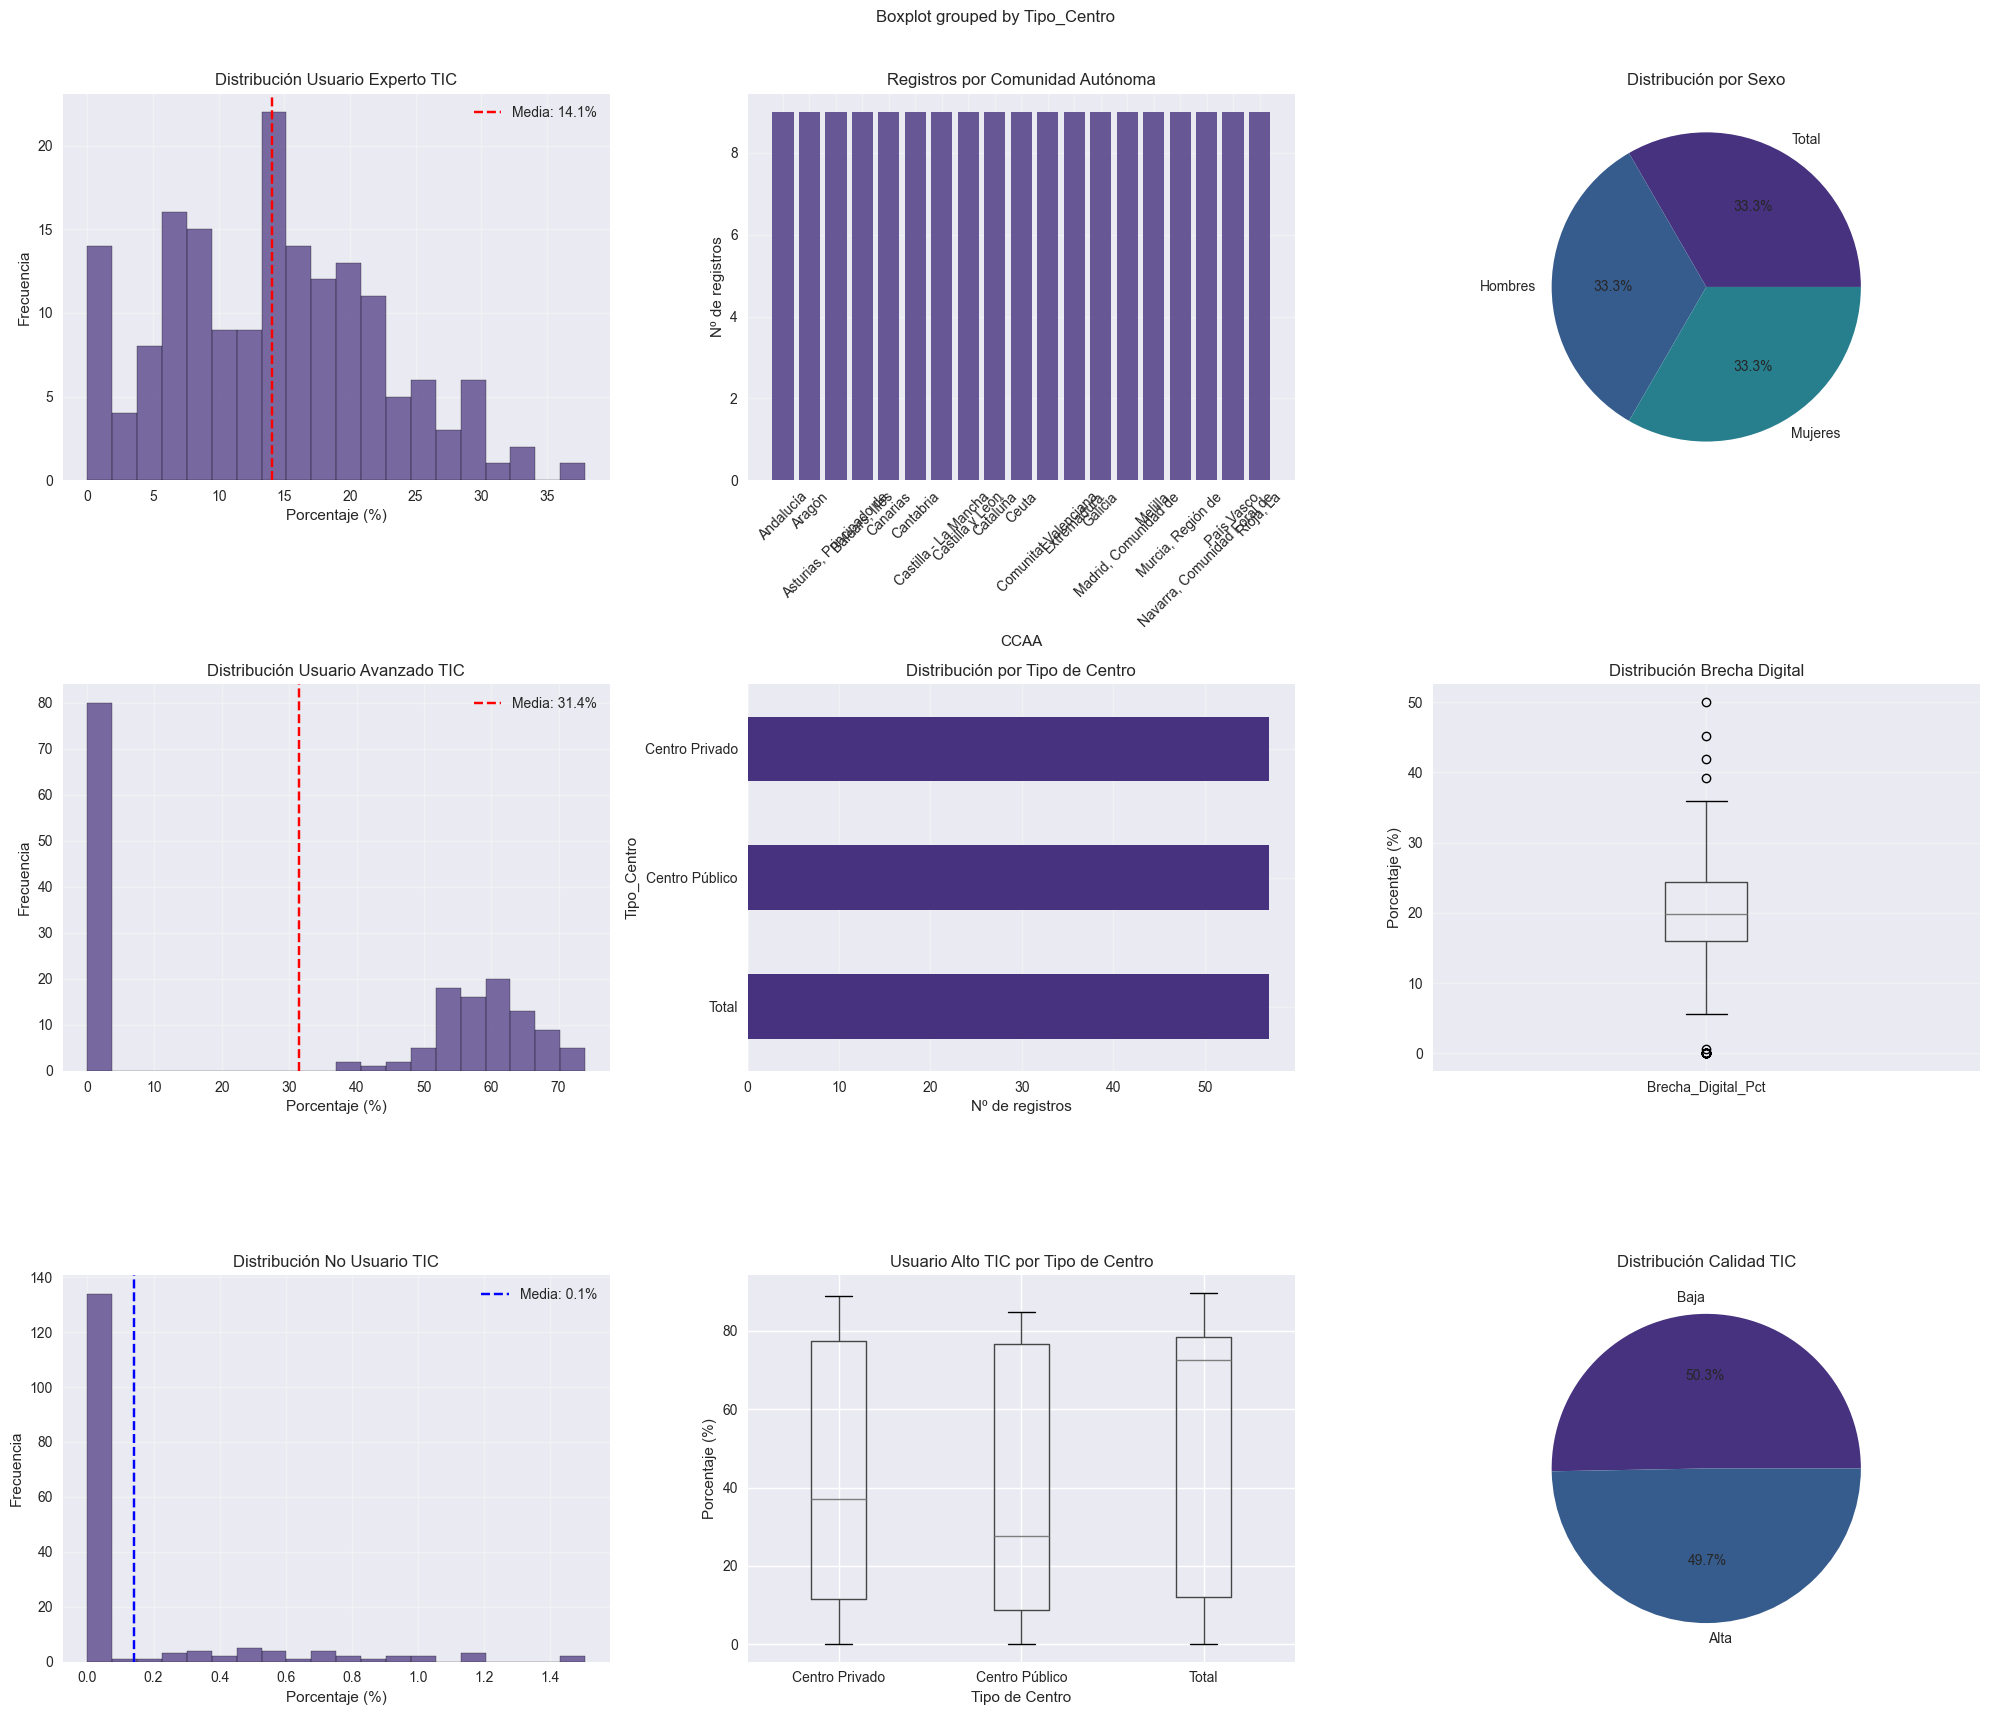

🖼️ Figura guardada en: ..\reports\figures\paso5_univariado.png


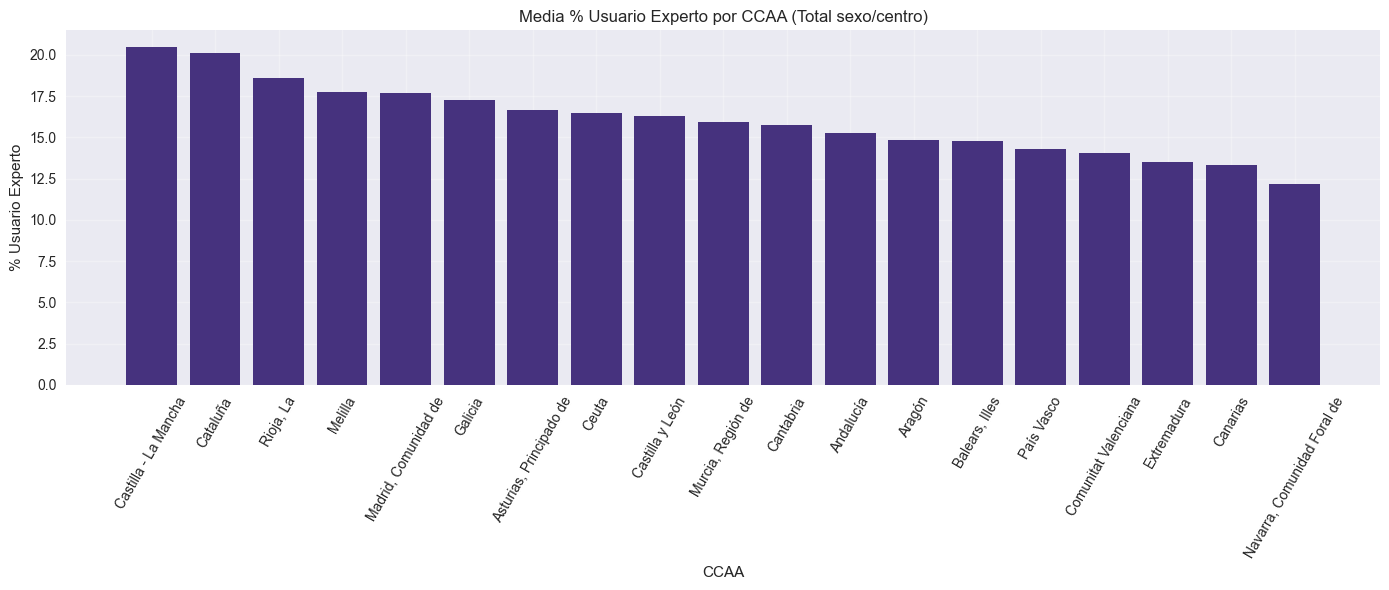

🖼️ Figura extra guardada en: ..\reports\figures\paso5_media_experto_por_ccaa.png

📈 ESTADÍSTICAS CLAVE DEL ANÁLISIS UNIVARIADO:
• Usuario Experto promedio: 14.1% (±8.2)
• Usuario Avanzado promedio: 31.4% (±29.9)
• Usuario Basico promedio: 19.0% (±9.2)
• No Usuario promedio: 0.1% (±0.3)

🏆 RANKINGS (Total sexo/centro, sin Total Nacional):
• Top 3 CCAA - Usuario Experto:
  1. Castilla - La Mancha: 20.5%
  2. Cataluña: 20.1%
  3. Rioja, La: 18.6%
• Top 3 CCAA - Mayor Brecha Digital:
  1. Melilla: 28.2%
  2. Andalucía: 27.4%
  3. Ceuta: 27.4%
📄 Tablas guardadas en: ..\reports\tables


In [21]:
# ============================================================================
# 📊 PASO 5: ANÁLISIS UNIVARIADO
# ============================================================================

"""
Analizamos cada variable de forma individual para entender su distribución,
tendencia central, dispersión y identificar patrones o anomalías.
Trabajamos con df_limpio (ancho en %) y excluimos 'Total Nacional' en comparativas por CCAA.
"""


def analisis_univariado(df):
    """Análisis univariado completo con visualizaciones y aretefactos"""
    print("\n" + "="*50)
    print("📊 ANÁLISIS UNIVARIADO")
    print("="*50)

    # ---- Config rutas para guardar artefactos ----
    fig_dir = Path("../reports/figures")
    tbl_dir = Path("../reports/tables")
    fig_dir.mkdir(parents=True, exist_ok=True)
    tbl_dir.mkdir(parents=True, exist_ok=True)

    # ---- Filtro base para comparativas por CCAA (evitar Total Nacional) ----
    df = df.copy()
    df_ccaa = df[df["CCAA"] != "Total Nacional"]

    # ---- Subconjuntos útiles para rankings globales (Total sexo y centro) ----
    mask_total = (
        (df_ccaa["Sexo"] == "Total") &
        (df_ccaa["Tipo_Centro"] == "Total")
    )
    df_total = df_ccaa.loc[mask_total].copy()


    # ================== Configurar figuras ==================
    # ================== figura principal (3x3) ==================

    fig, axes = plt.subplots(3, 3, figsize=(20, 18))
    fig.suptitle('🎓 Análisis Univariado - Habilidades TIC Graduados ESO',
                 fontsize=16, fontweight='bold')

    # 1. DISTRIBUCIÓN USUARIO EXPERTO
    df_ccaa['Usuario_Experto_Pct'].hist(bins=20, alpha=0.7,
                                        edgecolor='black', ax=axes[0,0])
    axes[0,0].axvline(df_ccaa['Usuario_Experto_Pct'].mean(),
                      color='red', linestyle='--',
                      label=f'Media: {df_ccaa['Usuario_Experto_Pct'].mean():.1f}%')
    axes[0,0].set_title('Distribución Usuario Experto TIC')
    axes[0,0].set_xlabel('Porcentaje (%)')
    axes[0,0].set_ylabel('Frecuencia')
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3)

    # 2. DISTRIBUCIÓN POR CCAA (nº de registros)
    # Nota: el dataset suele estar balanceado por combinaciones; el recuento es casi uniforme.
    ccaa_counts = (
        df_ccaa['CCAA']
        .value_counts()
        .sort_values(ascending=False)
    )
    axes[0,1].bar(ccaa_counts.index, ccaa_counts.values, alpha=0.8)
    axes[0,1].set_title('Registros por Comunidad Autónoma')
    axes[0,1].set_xlabel('CCAA')
    axes[0,1].set_ylabel('Nº de registros')
    axes[0,1].tick_params(axis='x', rotation=45)
    axes[0,1].grid(True, alpha=0.3)

    # 3. DISTRIBUCIÓN POR SEXO
    sexo_counts = df_ccaa['Sexo'].value_counts()
    axes[0,2].pie(sexo_counts.values, labels=sexo_counts.index, autopct='%1.1f%%')
    axes[0,2].set_title('Distribución por Sexo')

    # 4. DISTRIBUCIÓN USUARIO AVANZADO
    df_ccaa['Usuario_Avanzado_Pct'].hist(bins=20, alpha=0.7,
                                         edgecolor='black', ax=axes[1,0])
    axes[1,0].axvline(df_ccaa['Usuario_Avanzado_Pct'].mean(),
                      color='red', linestyle='--',
                      label=f'Media: {df_ccaa['Usuario_Avanzado_Pct'].mean():.1f}%')
    axes[1,0].set_title('Distribución Usuario Avanzado TIC')
    axes[1,0].set_xlabel('Porcentaje (%)')
    axes[1,0].set_ylabel('Frecuencia')
    axes[1,0].legend()
    axes[1,0].grid(True, alpha=0.3)

    # 5. TIPO DE CENTRO (recuento de filas)
    tipo_counts = df_ccaa['Tipo_Centro'].value_counts()
    tipo_counts.plot(kind='barh', ax=axes[1,1])
    axes[1,1].set_title('Distribución por Tipo de Centro')
    axes[1,1].set_xlabel('Nº de registros')
    axes[1,1].grid(True, alpha=0.3)

    # 6. BOXPLOT BRECHA DIGITAL
    df_ccaa.boxplot(column='Brecha_Digital_Pct', ax=axes[1,2])
    axes[1,2].set_title('Distribución Brecha Digital')
    axes[1,2].set_ylabel('Porcentaje (%)')
    axes[1,2].grid(True, alpha=0.3)

    # 7. DISTRIBUCIÓN NO USUARIO
    df_ccaa['No_Usuario_Pct'].hist(bins=20, alpha=0.7,
                                   edgecolor='black', ax=axes[2,0])
    axes[2,0].axvline(df_ccaa['No_Usuario_Pct'].mean(),
                      color='blue', linestyle='--',
                      label=f'Media: {df_ccaa['No_Usuario_Pct'].mean():.1f}%')
    axes[2,0].set_title('Distribución No Usuario TIC')
    axes[2,0].set_xlabel('Porcentaje (%)')
    axes[2,0].set_ylabel('Frecuencia')
    axes[2,0].legend()
    axes[2,0].grid(True, alpha=0.3)

    # 8. BOXPLOT USUARIO ALTO por tipo de centro
    df_ccaa.boxplot(column='Usuario_Alto_Pct', by='Tipo_Centro', ax=axes[2,1])
    axes[2,1].set_title('Usuario Alto TIC por Tipo de Centro')
    axes[2,1].set_xlabel('Tipo de Centro')
    axes[2,1].set_ylabel('Porcentaje (%)')

    # 9. DISTRIBUCIÓN CALIDAD TIC
    calidad_counts = df_ccaa['Calidad_TIC'].value_counts()
    axes[2,2].pie(calidad_counts.values, labels=calidad_counts.index, autopct='%1.1f%%')
    axes[2,2].set_title('Distribución Calidad TIC')

    plt.tight_layout(rect=[0, 0.03, 1, 0.97])
    out_fig = fig_dir / "paso5_univariado.png"
    plt.savefig(out_fig, dpi=150)
    plt.show()
    print(f"🖼️ Figura guardada en: {out_fig}")

    # -------- Figura extra: MEDIA % USUARIO EXPERTO POR CCAA (Total sexo/centro) --------
    if not df_total.empty:
        media_experto_ccaa = (
            df_total.groupby('CCAA', as_index=False)['Usuario_Experto_Pct']
            .mean()
            .sort_values('Usuario_Experto_Pct', ascending=False)
        )
        fig2, ax2 = plt.subplots(figsize=(14, 6))
        ax2.bar(media_experto_ccaa['CCAA'], media_experto_ccaa['Usuario_Experto_Pct'])
        ax2.set_title('Media % Usuario Experto por CCAA (Total sexo/centro)')
        ax2.set_xlabel('CCAA')
        ax2.set_ylabel('% Usuario Experto')
        ax2.tick_params(axis='x', rotation=60)
        ax2.grid(True, alpha=0.3)
        out_fig2 = fig_dir / "paso5_media_experto_por_ccaa.png"
        plt.tight_layout()
        plt.savefig(out_fig2, dpi=150)
        plt.show()
        print(f"🖼️ Figura extra guardada en: {out_fig2}")

        # Guardar la tabla también
        media_experto_ccaa.to_csv(tbl_dir / "media_experto_por_ccaa.csv", index=False)

    # ================== ESTADÍSTICAS CLAVE Y RANKINGS ==================
    print("\n📈 ESTADÍSTICAS CLAVE DEL ANÁLISIS UNIVARIADO:")
    print("="*50)
    for col in ['Usuario_Experto_Pct','Usuario_Avanzado_Pct','Usuario_Basico_Pct','No_Usuario_Pct']:
        print(f"• {col.replace('_Pct','').replace('_',' ')} promedio: "
              f"{df_ccaa[col].mean():.1f}% (±{df_ccaa[col].std():.1f})")

    print(f"\n🏆 RANKINGS (Total sexo/centro, sin Total Nacional):")
    if not df_total.empty:
        top_expertos = df_total.nlargest(3, 'Usuario_Experto_Pct')[['CCAA','Usuario_Experto_Pct']]
        top_brecha   = df_total.nlargest(3, 'Brecha_Digital_Pct')[['CCAA','Brecha_Digital_Pct']]

        print("• Top 3 CCAA - Usuario Experto:")
        for i, row in enumerate(top_expertos.itertuples(index=False), 1):
            print(f"  {i}. {row.CCAA}: {row.Usuario_Experto_Pct:.1f}%")

        print("• Top 3 CCAA - Mayor Brecha Digital:")
        for i, row in enumerate(top_brecha.itertuples(index=False), 1):
            print(f"  {i}. {row.CCAA}: {row.Brecha_Digital_Pct:.1f}%")

        # Guardar tablas
        top_expertos.to_csv(tbl_dir / "top3_ccaa_experto.csv", index=False)
        top_brecha.to_csv(tbl_dir / "top3_ccaa_brecha.csv", index=False)

    # Tabla resumen de estadísticas
    stats_tbl = (
        df_ccaa[['Usuario_Experto_Pct','Usuario_Avanzado_Pct','Usuario_Basico_Pct','No_Usuario_Pct']]
        .agg(['mean','std','min','max','median'])
        .T.rename_axis('Métrica')
    )
    stats_tbl.to_csv(tbl_dir / "univariado_estadisticas.csv")
    print(f"📄 Tablas guardadas en: {tbl_dir}")

# Ejecutar el análisis univariado con df_limpio (dataset ancho en %)
analisis_univariado(df_limpio)

**6: ANÁLISIS BIVARIADO**
============================
Analizamos las relaciones entre **pares de variables** para identificar correlaciones, dependencias y patrones de asociación.

Principalmente utilizamos para este análisis:
- **Herramientas estadísticas descriptivas** (medias por grupo)
- **Herramientas de visualización** como:
  - Barras comparativas por **Sexo** y **Tipo de centro**.
  - **Boxplots** comparativos por sexo.
  - **Plot** (término genérico para una visualización gráfica. La función plot() es genérica y crea un tipo de gráfico diferente dependiendo de los datos que se le pasen. Si le pasamos datos numéricos, plot() puede generar un gráfico de dispersión. Si le pasamos datos de tiempo, puede generar un gráfico de líneas.)
  - **Matriz de correlación** (tabla que muestra el coeficiente de correlación entre varias variables). Sirve para entender la fuerza y la dirección de la relación lineal entre pares de variables. A menudo se presenta como un mapa de calor (heatmap) para una mejor visualización.
  - scatter plot ó gráfico de dispersión (muestra la relación o la falta de ella entre dos variables cuantitativas, indicando su fuerza y dirección. Cada punto representa una observación con dos valores.)
  - **Scatter** Usuario Experto vs. Brecha Digital con **línea de tendencia**.
  - **Líneas de tendencia** (***polyfit*** se utiliza para encontrar los coeficientes de un polinomio que mejor se ajusta a un conjunto de datos (en el contexto de un gráfico de dispersión), minimizando la suma de los cuadrados de las diferencias entre los puntos de datos y el polinomio. En esencia, ajusta un polinomio a los puntos de un gráfico de dispersión para modelar la relación entre las variables).


 📋 **Análisis Bivariado**:
- Habilidades TIC por sexo
- Habilidades TIC por tipo de centro (Público/Privado)
- MATRIZ DE CORRELACIONES:
  - Correlaciones entre niveles TIC (tipo usuario Experto/Avanzado/Básico/No usuario o sin habilidades TIC)
- Distribución (dispersión/scatter plot) Usuario Experto vs. Brecha Digital
- Líneas de tendencia: Habilidades TIC por CCAA
- Distribución(Diagrama de caja/boxplot comparativo por sexo y tipo usuario)

- **RANKINGs territoriales por CCAA:**
  - Top 5 CCAA - con mayor % Usuarios Expertos
  - Las últimas 5 CCAA - con mayor brecha digital

- **Análisis Estadístico de correlaciones significativas:**
  - Correlaciones entre variables TIC

- **Análisis comparativo por grupos:**
  - Diferencias por sexo
  - Diferencias por tipo de centro

> Trabajamos con `df_limpio` (dataset **ancho en %**), excluyendo “**Total Nacional**” en comparativas por CCAA.



📊 ANÁLISIS BIVARIADO


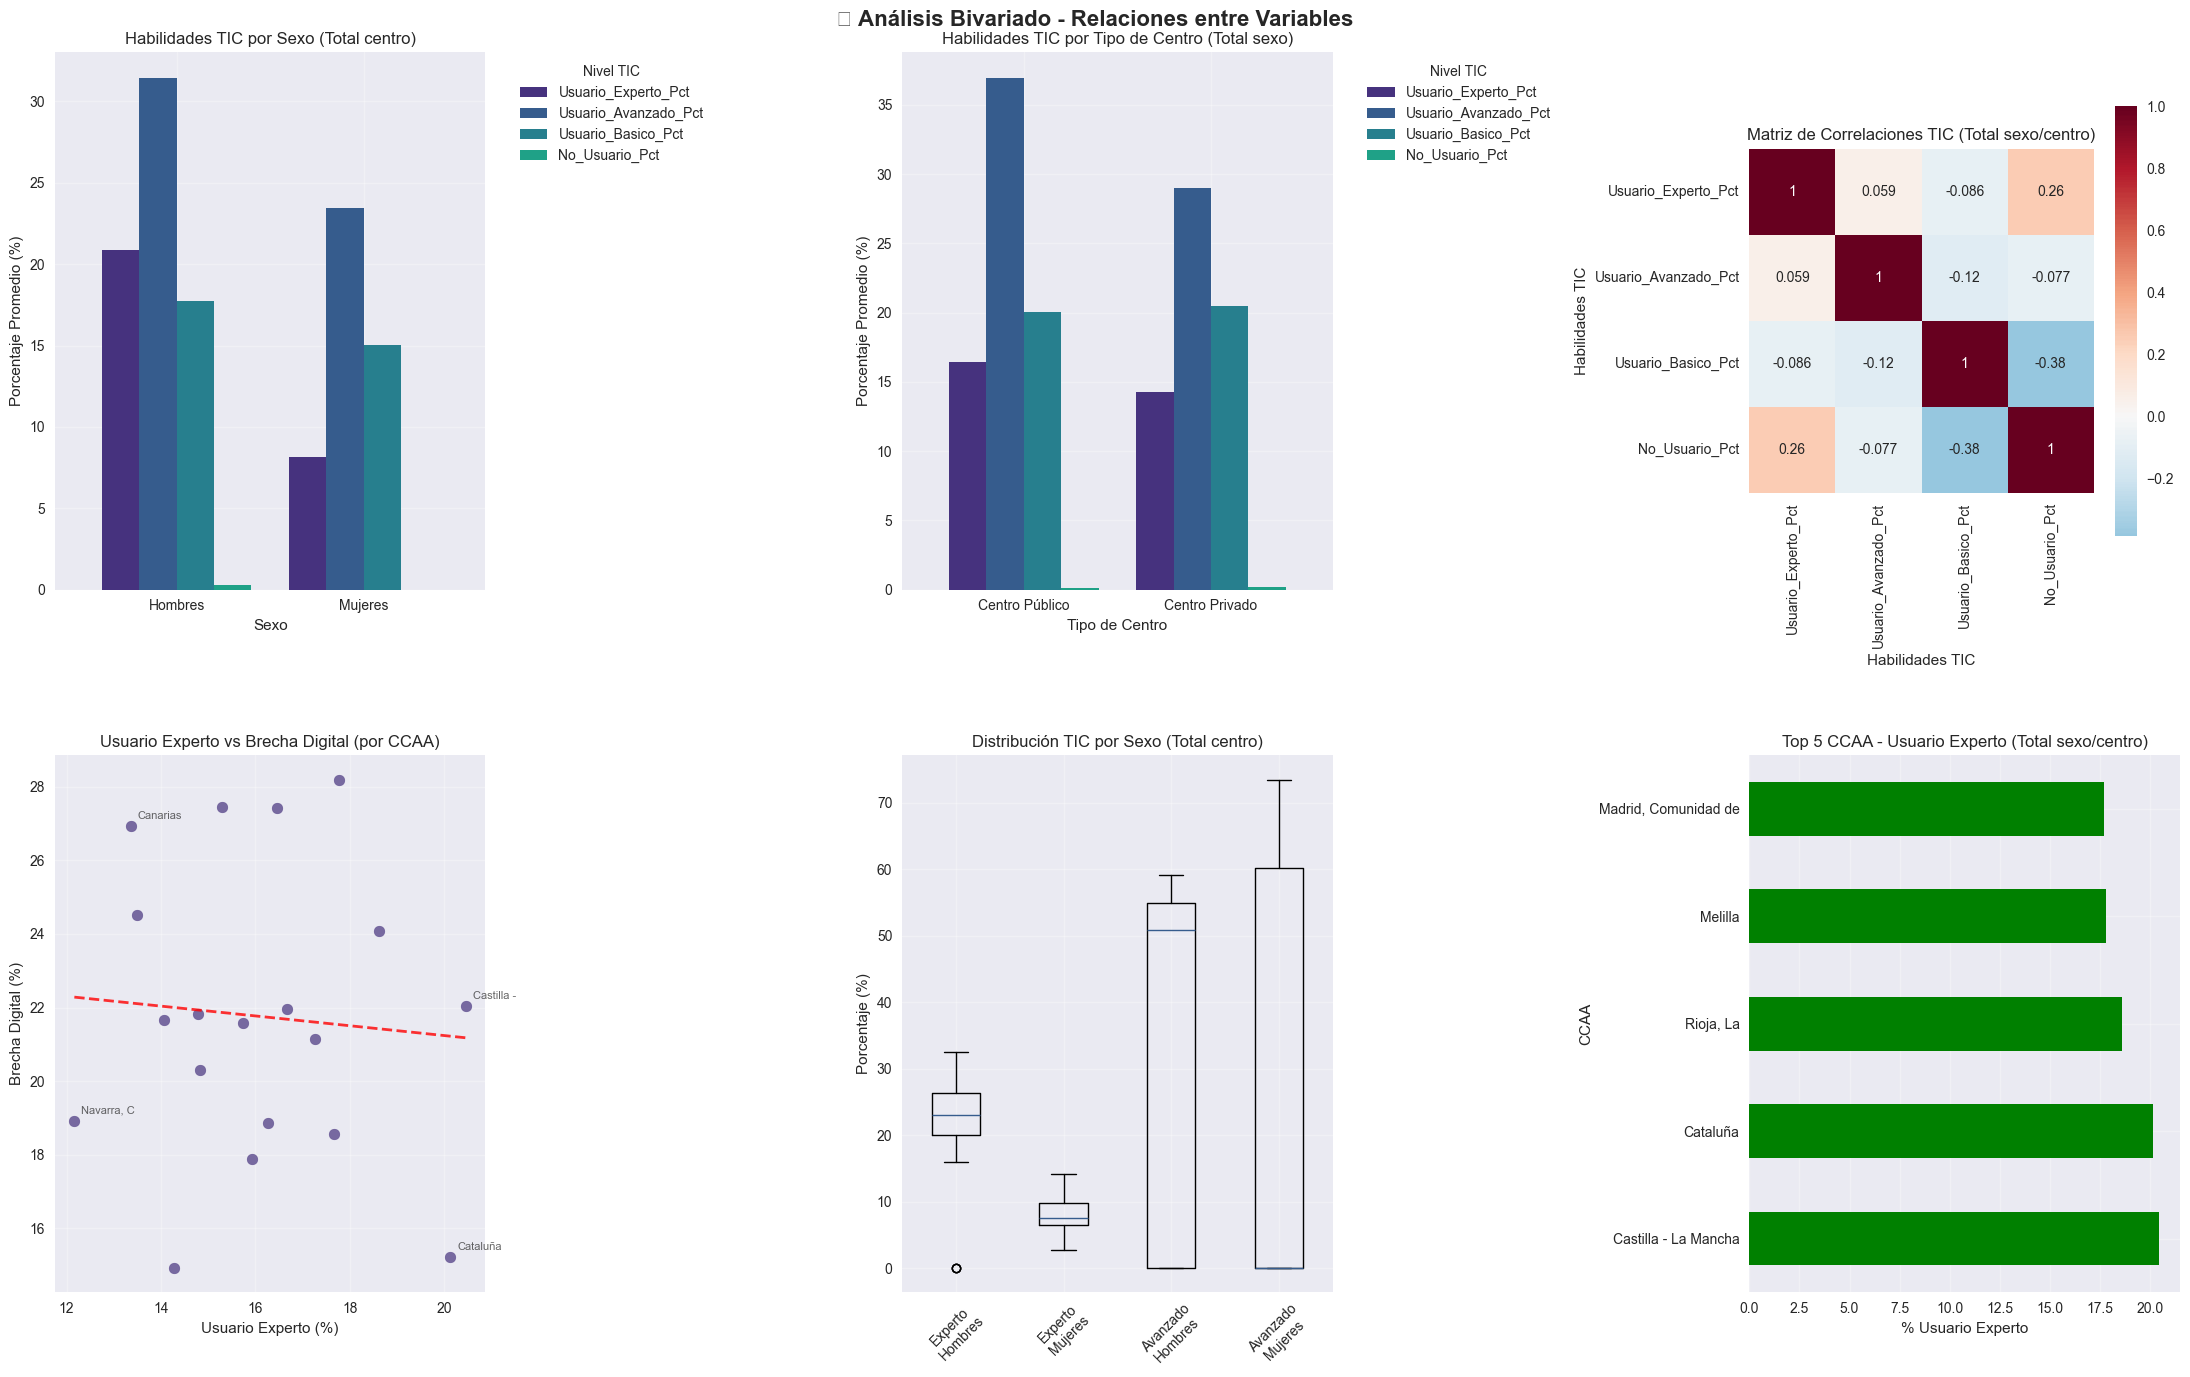

🖼️ Figura guardada en: ..\reports\figures\paso6_bivariado.png


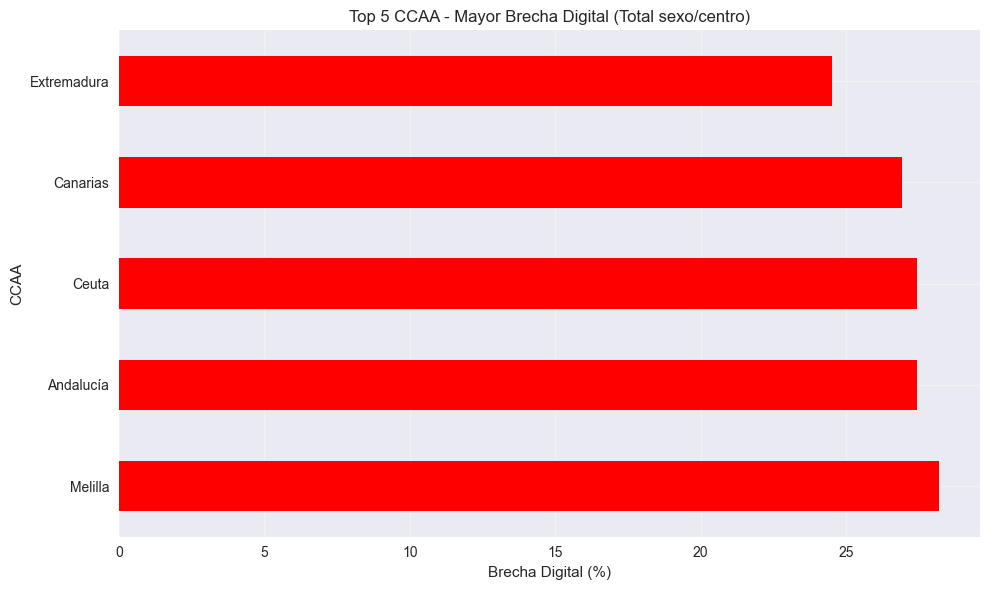

🖼️ Figura extra guardada en: ..\reports\figures\paso6_top5_brecha.png

🔗 ANÁLISIS DE CORRELACIONES (coeficiente y p-valor; Total sexo/centro)
------------------------------------------------------------
• Usuario_Experto_Pct ↔ Usuario_Avanzado_Pct: r=0.059, p=0.8100 → débil positiva
• Usuario_Experto_Pct ↔ Usuario_Basico_Pct: r=-0.086, p=0.7267 → débil negativa
• Usuario_Experto_Pct ↔ No_Usuario_Pct: r=0.257, p=0.2875 → débil positiva
• Usuario_Avanzado_Pct ↔ Usuario_Basico_Pct: r=-0.118, p=0.6309 → débil negativa
• Usuario_Avanzado_Pct ↔ No_Usuario_Pct: r=-0.077, p=0.7551 → débil negativa
• Usuario_Basico_Pct ↔ No_Usuario_Pct: r=-0.383, p=0.1051 → moderada negativa

📊 DIFERENCIAS POR GRUPOS (t-test de medias)
------------------------------------------------------------
• Usuario_Experto_Pct (H vs M): Δ=+12.75 pp, t=5.31, p=0.0000
• Usuario_Experto_Pct (Privado - Público): Δ=-2.19 pp, t=-1.64, p=0.1098


In [22]:
# ============================================================================
# 📊 PASO 6: ANÁLISIS BIVARIADO
# ============================================================================

"""
Analizamos las relaciones entre pares de variables para identificar
correlaciones, dependencias y patrones de asociación.
"""

def analisis_bivariado(df):
    """Análisis bivariado con visualizaciones avanzadas y tests de significación."""
    print("\n" + "="*50)
    print("📊 ANÁLISIS BIVARIADO")
    print("="*50)

    # ----------------- Rutas de artefactos -----------------
    fig_dir = Path("../reports/figures")
    tbl_dir = Path("../reports/tables")
    fig_dir.mkdir(parents=True, exist_ok=True)
    tbl_dir.mkdir(parents=True, exist_ok=True)

    # ----------------- Copia y estandarización -----------------
    df = df.copy()

    # Normalizamos etiquetas de centro por si hubieran variantes
    df["Tipo_Centro"] = df["Tipo_Centro"].replace({
        "Públicos": "Centro Público",
        "Publicos": "Centro Público",
        "Centros públicos": "Centro Público",
        "Privados": "Centro Privado",
        "Centros privados": "Centro Privado",
        "Publico": "Centro Público",
        "Privado": "Centro Privado",
    })

    # Excluir Total Nacional para comparativas territoriales
    df_ccaa = df[df["CCAA"] != "Total Nacional"].copy()

    # Subconjunto para evitar duplicidades en correlación/rankings:
    # Solo Total (sexo) y Total (centro)
    mask_total = (df_ccaa["Sexo"] == "Total") & (df_ccaa["Tipo_Centro"] == "Total")
    df_total = df_ccaa.loc[mask_total].copy()

    variables_tic = ['Usuario_Experto_Pct','Usuario_Avanzado_Pct','Usuario_Basico_Pct','No_Usuario_Pct']

    # ----------------- Configurar figuras -----------------
    # -----------------     figura  2 x 3  -----------------


    fig, axes = plt.subplots(2, 3, figsize=(22, 14))
    fig.suptitle('🔗 Análisis Bivariado - Relaciones entre Variables',
                 fontsize=16, fontweight='bold')

    # 1) HABILIDADES TIC POR SEXO (Total centro)
    df_sexo = df_ccaa[(df_ccaa['Tipo_Centro'] == 'Total') & (df_ccaa['Sexo'].isin(['Hombres','Mujeres']))]
    df_sexo_grouped = df_sexo.groupby('Sexo')[variables_tic].mean().reindex(['Hombres','Mujeres'])
    df_sexo_grouped.plot(kind='bar', ax=axes[0,0], width=0.8)
    axes[0,0].set_title('Habilidades TIC por Sexo (Total centro)')
    axes[0,0].set_xlabel('Sexo')
    axes[0,0].set_ylabel('Porcentaje Promedio (%)')
    axes[0,0].legend(title='Nivel TIC', bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[0,0].tick_params(axis='x', rotation=0)
    axes[0,0].grid(True, alpha=0.3)

    # 2) HABILIDADES TIC POR TIPO DE CENTRO (Total sexo)
    df_centro = df_ccaa[(df_ccaa['Sexo'] == 'Total') & (df_ccaa['Tipo_Centro'].isin(['Centro Público','Centro Privado']))]
    df_centro_grouped = df_centro.groupby('Tipo_Centro')[variables_tic].mean().reindex(['Centro Público','Centro Privado'])
    df_centro_grouped.plot(kind='bar', ax=axes[0,1], width=0.8)
    axes[0,1].set_title('Habilidades TIC por Tipo de Centro (Total sexo)')
    axes[0,1].set_xlabel('Tipo de Centro')
    axes[0,1].set_ylabel('Porcentaje Promedio (%)')
    axes[0,1].legend(title='Nivel TIC', bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[0,1].tick_params(axis='x', rotation=0)
    axes[0,1].grid(True, alpha=0.3)

    # 3) MATRIZ DE CORRELACIÓN (sobre Total sexo/centro)
    corr_df = df_total[variables_tic].copy()
    corr_mat = corr_df.corr()
    sns.heatmap(corr_mat, annot=True, cmap='RdBu_r', center=0, square=True,
                ax=axes[0,2], cbar_kws={'shrink': 0.8})
    axes[0,2].set_title('Matriz de Correlaciones TIC (Total sexo/centro)')

    # 4) SCATTER: USUARIO EXPERTO vs BRECHA (Total sexo/centro, una fila por CCAA)
    df_scatter = df_total.dropna(subset=['Usuario_Experto_Pct','Brecha_Digital_Pct']).copy()
    axes[1,0].scatter(df_scatter['Usuario_Experto_Pct'], df_scatter['Brecha_Digital_Pct'],
                      alpha=0.7, s=60)
    # Línea de tendencia (ajuste lineal)
    x = df_scatter['Usuario_Experto_Pct'].values
    y = df_scatter['Brecha_Digital_Pct'].values
    if len(x) >= 2:
        z = np.polyfit(x, y, 1)
        p = np.poly1d(z)
        xs = np.linspace(x.min(), x.max(), 100)
        axes[1,0].plot(xs, p(xs), "r--", alpha=0.8, linewidth=2)
    axes[1,0].set_title('Usuario Experto vs Brecha Digital (por CCAA)')
    axes[1,0].set_xlabel('Usuario Experto (%)')
    axes[1,0].set_ylabel('Brecha Digital (%)')
    axes[1,0].grid(True, alpha=0.3)
    # Etiquetas para extremos
    q10, q90 = df_scatter['Usuario_Experto_Pct'].quantile([0.10, 0.90])
    for _, row in df_scatter.iterrows():
        if (row['Usuario_Experto_Pct'] <= q10) or (row['Usuario_Experto_Pct'] >= q90):
            axes[1,0].annotate(row['CCAA'][:10], (row['Usuario_Experto_Pct'], row['Brecha_Digital_Pct']),
                               xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.7)

    # 5) BOXPLOT COMPARATIVO POR SEXO (Total centro)
    df_box = df_ccaa[(df_ccaa['Tipo_Centro'] == 'Total') & (df_ccaa['Sexo'].isin(['Hombres','Mujeres']))]
    datos_boxplot, labels_boxplot = [], []
    for nivel, label in [('Usuario_Experto_Pct','Experto'), ('Usuario_Avanzado_Pct','Avanzado')]:
        for sexo in ['Hombres','Mujeres']:
            vals = df_box[df_box['Sexo']==sexo][nivel].dropna()
            datos_boxplot.append(vals)
            labels_boxplot.append(f"{label}\n{sexo}")
    axes[1,1].boxplot(datos_boxplot, labels=labels_boxplot)
    axes[1,1].set_title('Distribución TIC por Sexo (Total centro)')
    axes[1,1].set_ylabel('Porcentaje (%)')
    axes[1,1].tick_params(axis='x', rotation=45)
    axes[1,1].grid(True, alpha=0.3)

    # 6) RANKINGS TERRITORIALES (Total sexo/centro)
    df_territorial = df_total.copy()
    top5_experto = df_territorial.nlargest(5, 'Usuario_Experto_Pct')[['CCAA','Usuario_Experto_Pct']]
    top5_brecha  = df_territorial.nlargest(5, 'Brecha_Digital_Pct')[['CCAA','Brecha_Digital_Pct']]

    extremos = pd.concat([
        top5_experto.assign(_grupo='Top Experto'),
        top5_brecha.assign(_grupo='Top Brecha')
    ], axis=0)

    # Mostrar Top 5 expertos (verde) y Top 5 brecha (rojo) juntos
    # Para la figura principal dejamos el Top 5 expertos
    top5_experto.set_index('CCAA')['Usuario_Experto_Pct'].plot(kind='barh',
                                                               color='green', ax=axes[1,2])
    axes[1,2].set_title('Top 5 CCAA - Usuario Experto (Total sexo/centro)')
    axes[1,2].set_xlabel('% Usuario Experto')
    axes[1,2].grid(True, alpha=0.3)

    plt.tight_layout()
    out_fig = fig_dir / "paso6_bivariado.png"
    plt.savefig(out_fig, dpi=150)
    plt.show()
    print(f"🖼️ Figura guardada en: {out_fig}")

    # ---- Figura extra: Top 5 Brecha Digital ----
    fig2, ax2 = plt.subplots(figsize=(10, 6))
    top5_brecha.set_index('CCAA')['Brecha_Digital_Pct'].plot(kind='barh', color='red', ax=ax2)
    ax2.set_title('Top 5 CCAA - Mayor Brecha Digital (Total sexo/centro)')
    ax2.set_xlabel('Brecha Digital (%)')
    ax2.grid(True, alpha=0.3)
    out_fig2 = fig_dir / "paso6_top5_brecha.png"
    plt.tight_layout()
    plt.savefig(out_fig2, dpi=150)
    plt.show()
    print(f"🖼️ Figura extra guardada en: {out_fig2}")

    # Guardar tablas
    df_sexo_grouped.reset_index().to_csv(tbl_dir / "biv_sexo_medias.csv", index=False)
    df_centro_grouped.reset_index().to_csv(tbl_dir / "biv_centro_medias.csv", index=False)
    corr_mat.to_csv(tbl_dir / "biv_corr_matrix.csv")
    top5_experto.to_csv(tbl_dir / "biv_top5_experto.csv", index=False)
    top5_brecha.to_csv(tbl_dir / "biv_top5_brecha.csv", index=False)

    # ----------------- Significación estadística -----------------
    print("\n🔗 ANÁLISIS DE CORRELACIONES (coeficiente y p-valor; Total sexo/centro)")
    print("-"*60)
    for i, v1 in enumerate(variables_tic):
        for v2 in variables_tic[i+1:]:
            x = df_total[v1].dropna()
            y = df_total[v2].dropna()
            # Alinear índices por si no coinciden
            aligned = df_total[[v1, v2]].dropna()
            if len(aligned) >= 3:
                r, p = pearsonr(aligned[v1], aligned[v2])
                fuerza = "fuerte" if abs(r) > 0.7 else ("moderada" if abs(r) > 0.3 else "débil")
                direccion = "positiva" if r > 0 else "negativa"
                sig = " (p<0.05)" if p < 0.05 else ""
                print(f"• {v1} ↔ {v2}: r={r:.3f}, p={p:.4f} → {fuerza} {direccion}{sig}")

    # ----------------- Comparativas por grupos (t-tests) -----------------
    print("\n📊 DIFERENCIAS POR GRUPOS (t-test de medias)")
    print("-"*60)
    # Sexo (H vs M) sobre Total centro
    hombres = df_ccaa[(df_ccaa['Sexo']=='Hombres') & (df_ccaa['Tipo_Centro']=='Total')]['Usuario_Experto_Pct'].dropna()
    mujeres = df_ccaa[(df_ccaa['Sexo']=='Mujeres') & (df_ccaa['Tipo_Centro']=='Total')]['Usuario_Experto_Pct'].dropna()
    if len(hombres) >= 2 and len(mujeres) >= 2:
        t_stat, p_val = ttest_ind(hombres, mujeres, equal_var=False)
        print(f"• Usuario_Experto_Pct (H vs M): Δ={hombres.mean()-mujeres.mean():+.2f} pp, t={t_stat:.2f}, p={p_val:.4f}")

    # Tipo de centro (Privado vs Público) sobre Total sexo
    pub = df_ccaa[(df_ccaa['Tipo_Centro']=='Centro Público') & (df_ccaa['Sexo']=='Total')]['Usuario_Experto_Pct'].dropna()
    pri = df_ccaa[(df_ccaa['Tipo_Centro']=='Centro Privado') & (df_ccaa['Sexo']=='Total')]['Usuario_Experto_Pct'].dropna()
    if len(pub) >= 2 and len(pri) >= 2:
        t_stat, p_val = ttest_ind(pri, pub, equal_var=False)
        print(f"• Usuario_Experto_Pct (Privado - Público): Δ={pri.mean()-pub.mean():+.2f} pp, t={t_stat:.2f}, p={p_val:.4f}")

# Ejecutar el análisis bivariado con df_limpio (dataset ancho en %)
analisis_bivariado(df_limpio)

In [23]:
# ============================================================================
# ♻️ PASO 6.1. Guarda figuras estáticas para añadir al informe ejecutivo (PDF)
#           (univariado/bivariado) (robusto ante categorías vacías)
# ============================================================================

def _norm_centro(series: pd.Series) -> pd.Series:
    """Normaliza valores de Tipo_Centro a {'Públicos','Privados','Total','Otro'} con tolerancia."""
    s = series.astype(str).str.strip().str.lower()
    def map_one(x):
        if "privad" in x: return "Privados"
        if "públic" in x or "public" in x: return "Públicos"
        if "total" in x: return "Total"
        return "Otro"
    return s.map(map_one)

def _safe_save(figpath: Path):
    figpath.parent.mkdir(parents=True, exist_ok=True)
    plt.tight_layout()
    plt.savefig(figpath, dpi=160, bbox_inches="tight")
    plt.close()

def guardar_figuras_para_pdf(df: pd.DataFrame) -> list[Path]:
    fig_dir = Path("../reports/figures"); fig_dir.mkdir(parents=True, exist_ok=True)
    saved = []

    # --- Alcance base coherente para comparativas territoriales:
    base = df[(df["CCAA"]!="Total Nacional")].copy()

    # ---------------- 1) Univariado: Histograma Usuario Experto ----------------
    try:
        plt.figure(figsize=(7,5))
        base["Usuario_Experto_Pct"].hist(bins=18, edgecolor="black")
        plt.title("Distribución % Usuario Experto (todos los registros)")
        plt.xlabel("%"); plt.ylabel("Frecuencia")
        out = fig_dir/"uni_hist_experto.png"
        _safe_save(out); saved.append(out)
    except Exception as e:
        print("⚠️ No se pudo generar uni_hist_experto.png:", e)

    # ---------------- 2) Univariado: Boxplot Brecha Digital ----------------
    try:
        plt.figure(figsize=(5,5))
        sns.boxplot(y=base["Brecha_Digital_Pct"])
        plt.title("Brecha Digital (Básico+No usuario) — Boxplot")
        plt.ylabel("%")
        out = fig_dir/"uni_box_brecha.png"
        _safe_save(out); saved.append(out)
    except Exception as e:
        print("⚠️ No se pudo generar uni_box_brecha.png:", e)

    # ---------------- 3) Bivariado: Matriz de correlaciones ----------------
    try:
        plt.figure(figsize=(6,5))
        cols = ["Usuario_Experto_Pct","Usuario_Avanzado_Pct","Usuario_Basico_Pct","No_Usuario_Pct","Brecha_Digital_Pct"]
        corr = base[cols].corr()
        sns.heatmap(corr, annot=True, cmap="RdBu_r", center=0, square=True, cbar_kws={"shrink":0.8})
        plt.title("Matriz de correlaciones (porcentajes)")
        out = fig_dir/"bi_heatmap_correlaciones.png"
        _safe_save(out); saved.append(out)
    except Exception as e:
        print("⚠️ No se pudo generar bi_heatmap_correlaciones.png:", e)

    # ---------------- 4) Bivariado: Barras por Sexo ----------------
    try:
        df_sexo = base[(base["Sexo"].isin(["Hombres","Mujeres"])) & (base["Tipo_Centro"]=="Total")].copy()
        if df_sexo.empty:
            print("ℹ️ Gráfico por sexo: sin filas con Sexo∈{Hombres,Mujeres} y Tipo_Centro=Total (se omite).")
        else:
            medios = (df_sexo.groupby("Sexo")[["Usuario_Experto_Pct","Usuario_Avanzado_Pct",
                                               "Usuario_Basico_Pct","No_Usuario_Pct"]]
                      .mean().rename(columns={
                          "Usuario_Experto_Pct":"Experto",
                          "Usuario_Avanzado_Pct":"Avanzado",
                          "Usuario_Basico_Pct":"Basico",
                          "No_Usuario_Pct":"No_Usuario"
                      }))
            plt.figure(figsize=(7,5))
            medios[["Experto","Avanzado","Basico","No_Usuario"]].plot(kind="bar", ax=plt.gca())
            plt.title("Medias por Sexo (Tipo_Centro=Total, sin Total Nacional)")
            plt.ylabel("%"); plt.xticks(rotation=0); plt.legend(title="Nivel TIC")
            out = fig_dir/"bi_barras_sexo.png"
            _safe_save(out); saved.append(out)
    except Exception as e:
        print("⚠️ No se pudo generar bi_barras_sexo.png:", e)

    # ---------------- 5) Bivariado: Barras por Tipo de Centro ----------------
    try:
        df_cent = base[base["Sexo"]=="Total"].copy()
        if "Tipo_Centro" in df_cent.columns:
            df_cent["Tipo_Centro_norm"] = _norm_centro(df_cent["Tipo_Centro"])
            df_cent = df_cent[df_cent["Tipo_Centro_norm"].isin(["Públicos","Privados"])]
        else:
            df_cent["Tipo_Centro_norm"] = np.nan

        if df_cent.empty:
            print("ℹ️ Gráfico por centro: sin filas para Sexo=Total con Públicos/Privados (se omite).")
        else:
            gc = (df_cent.groupby("Tipo_Centro_norm")[["Usuario_Experto_Pct","Usuario_Avanzado_Pct",
                                                       "Usuario_Basico_Pct","No_Usuario_Pct"]]
                  .mean().rename(columns={
                      "Usuario_Experto_Pct":"Experto",
                      "Usuario_Avanzado_Pct":"Avanzado",
                      "Usuario_Basico_Pct":"Basico",
                      "No_Usuario_Pct":"No_Usuario"
                  }))

            if gc.empty:
                print("ℹ️ Gráfico por centro: agrupación vacía tras normalizar (se omite).")
            else:
                plt.figure(figsize=(7,5))
                gc[["Experto","Avanzado","Basico","No_Usuario"]].plot(kind="bar", ax=plt.gca())
                plt.title("Medias por Tipo de Centro (Sexo=Total, sin Total Nacional)")
                plt.ylabel("%"); plt.xticks(rotation=0); plt.legend(title="Nivel TIC")
                out = fig_dir/"bi_barras_centro.png"
                _safe_save(out); saved.append(out)
    except Exception as e:
        print("⚠️ No se pudo generar bi_barras_centro.png:", e)

    print("✅ Figuras guardadas en:", fig_dir.resolve())
    return saved

# Ejecuta para generar/actualizar las figuras
guardar_figuras_para_pdf(df_limpio)


✅ Figuras guardadas en: C:\dev\proyectos\eda_graduados_eso_tic\reports\figures


[WindowsPath('../reports/figures/uni_hist_experto.png'),
 WindowsPath('../reports/figures/uni_box_brecha.png'),
 WindowsPath('../reports/figures/bi_heatmap_correlaciones.png'),
 WindowsPath('../reports/figures/bi_barras_sexo.png'),
 WindowsPath('../reports/figures/bi_barras_centro.png')]

**7: PRUEBAS DE HIPÓTESIS**
============================
Realizamos pruebas estadísticas para validar nuestras observaciones y determinar si las diferencias encontradas son estadísticamente significativas.

Principalmente utilizamos para este análisis:

-**Comparación entre Grupos:**
Cuando se trabaja con datos categóricos y numéricos, es importante comparar los diferentes grupos para identificar diferencias significativas:

  - **Pruebas estadísticas:**

    - **T-test**: Compara la media de dos grupos para determinar si son significativamente diferentes.
      - **t-test (Welch)** Hombres vs. Mujeres (sobre `% Usuario experto`, Total centro).
      - **t-test (Welch)** Privado vs. Público (sobre `% Usuario experto`, Total sexo).
    - **ANOVA**: Evalúa diferencias entre más de dos grupos. Entre **tipos de centro** (Público / Privado / Total) con réplicas por CCAA.
    
- **Asociación**:
  - **Chi-cuadrado** Determina si hay asociación entre variables categóricas. De independencia: **CCAA × Nivel TIC** (Bajo/Medio/Alto) discretizado desde `% Usuario experto`.


  - **Herramientas de visualización:**
  - **tabla de contingencias** (tabla estadística que organiza y resume datos de dos o más variables categóricas para mostrar la frecuencia con la que las combinaciones de sus valores ocurren conjuntamente, permitiendo así analizar la asociación o relación entre estas variables. Cada celda de la tabla contiene el conteo de frecuencias de una combinación específica de las categorías de las variables.)

Reportamos:
- Coeficientes, **p-valores**, **tamaños de efecto** (Cohen’s *d* / Hedges’ *g*) y **IC 95%** donde aplica.
- Artefactos en `reports/tables/` y un resumen en `reports/hypothesis_tests.md`.


Nota: 
- Usamos Welch en los t-tests (no asume varianzas iguales).
- Reportamos Cohen’s d y Hedges’ g (tamaño de efecto) y IC 95% de la diferencia de medias.
- El ANOVA se hace entre tipos de centro porque aporta muchas réplicas (una por CCAA), a diferencia de un ANOVA “por CCAA” con una sola fila por CCAA (no tendría varianza intra-grupo).


> Trabajamos con `df_limpio` (dataset **ancho en %**) y **excluimos “Total Nacional”** en comparativas por CCAA.



In [24]:
# ============================================================================
# 🧪 PASO 7: PRUEBAS DE HIPÓTESIS ESTADÍSTICAS
# ============================================================================
'''
Realizamos pruebas estadísticas para validar nuestras observaciones
y determinar si las diferencias encontradas son estadísticamente significativas.
'''

def _cohens_d(a, b):
    """Cohen's d y Hedges' g para dos muestras (a=grupo1, b=grupo2)."""
    a = pd.Series(a).dropna()
    b = pd.Series(b).dropna()
    n1, n2 = len(a), len(b)
    if n1 < 2 or n2 < 2:
        return np.nan, np.nan
    s1, s2 = a.std(ddof=1), b.std(ddof=1)
    s_pooled = np.sqrt(((n1 - 1)*s1**2 + (n2 - 1)*s2**2) / (n1 + n2 - 2)) if (n1+n2-2) > 0 else np.nan
    d = (a.mean() - b.mean()) / s_pooled if s_pooled and s_pooled > 0 else np.nan
    # Hedges' g (corrección por small sample)
    g = d * (1 - 3/(4*(n1+n2)-9)) if (n1+n2) > 3 else d
    return float(d), float(g)

def _welch_ci(a, b, alpha=0.05):
    """IC del 95% para la diferencia de medias (a - b) con Welch."""
    a = pd.Series(a).dropna()
    b = pd.Series(b).dropna()
    n1, n2 = len(a), len(b)
    if n1 < 2 or n2 < 2:
        return (np.nan, np.nan, np.nan)
    m1, m2 = a.mean(), b.mean()
    v1, v2 = a.var(ddof=1), b.var(ddof=1)
    se = np.sqrt(v1/n1 + v2/n2)
    if se == 0:
        return (np.nan, np.nan, np.nan)
    # Welch–Satterthwaite df
    df = (v1/n1 + v2/n2)**2 / ((v1/n1)**2/(n1-1) + (v2/n2)**2/(n2-1))
    tcrit = t.ppf(1 - alpha/2, df)
    diff = m1 - m2
    lo, hi = diff - tcrit*se, diff + tcrit*se
    return float(lo), float(hi), float(df)


def pruebas_hipotesis(df):
    """Pruebas de hipótesis estadísticas completas con artefactos de salida."""
    print("\n" + "="*50)
    print("🧪 PRUEBAS DE HIPÓTESIS ESTADÍSTICAS")
    print("="*50)

     # ---- Rutas para artefactos
    tbl_dir = Path("../reports/tables")
    tbl_dir.mkdir(parents=True, exist_ok=True)
    out_md = Path("../reports/hypothesis_tests.md")

    # ---- Preparación de datos
    df = df.copy()
    # Estandariza Tipo_Centro (por si hubieran variantes)
    df["Tipo_Centro"] = df["Tipo_Centro"].replace({
        "Públicos": "Centro Público", "Publicos": "Centro Público",
        "Centros públicos": "Centro Público", "Publico": "Centro Público",
        "Privados": "Centro Privado", "Centros privados": "Centro Privado",
        "Privado": "Centro Privado"
    })

    
    # Excluye Total Nacional cuando toque
    df_ccaa = df[df["CCAA"] != "Total Nacional"].copy()

    resultados = {}


    # ==========================
    # H1: Género (Welch t-test)
    # ==========================
    
    # HIPÓTESIS 1: ¿Existe diferencia significativa en habilidades TIC entre hombres y mujeres?
    print("\n📊 HIPÓTESIS 1: Diferencias por género en % Usuario experto (Total centro)")
    print("H₀: μHombres = μMujeres   |   H₁: μHombres ≠ μMujeres")

    df_gen = df_ccaa[(df_ccaa["Sexo"].isin(["Hombres","Mujeres"])) & (df_ccaa["Tipo_Centro"]=="Total")]
    hombres = df_gen[df_gen["Sexo"]=="Hombres"]["Usuario_Experto_Pct"].dropna()
    mujeres = df_gen[df_gen["Sexo"]=="Mujeres"]["Usuario_Experto_Pct"].dropna()

    if len(hombres) >= 2 and len(mujeres) >= 2:
        t_stat, p_val = ttest_ind(hombres, mujeres, equal_var=False)  # Welch
        d, g = _cohens_d(hombres, mujeres)
        lo, hi, df_w = _welch_ci(hombres, mujeres)
        print(f"   • Media H: {hombres.mean():.2f}% (n={len(hombres)}) | Media M: {mujeres.mean():.2f}% (n={len(mujeres)})")
        print(f"   • t={t_stat:.3f} (df≈{df_w:.1f}), p={p_val:.4f}, d={d:.2f}, g={g:.2f}, IC95% Δ=[{lo:.2f},{hi:.2f}] pp")
        print("   →", "✅ Rechazamos H₀ (α=0.05)" if p_val < 0.05 else "❌ No rechazamos H₀ (α=0.05)")
        resultados["t_genero_p"] = float(p_val)
        resultados["t_genero_diff"] = float(hombres.mean() - mujeres.mean())
    else:
        print("   ⚠️ Muestras insuficientes para el t-test H vs M.")
        resultados["t_genero_p"] = None

    # ==========================================
    # H2: Tipo de Centro (Welch t-test Priv–Púb)
    # ==========================================
    print("\n📊 HIPÓTESIS 2: Diferencias Centros Privados vs Públicos en % Usuario experto (Total sexo)")
    print("H₀: μPrivados = μPúblicos   |   H₁: μPrivados ≠ μPúblicos")

    df_cen = df_ccaa[(df_ccaa["Sexo"]=="Total") & (df_ccaa["Tipo_Centro"].isin(["Centro Público","Centro Privado"]))]

    pub = df_cen[df_cen["Tipo_Centro"]=="Centro Público"]["Usuario_Experto_Pct"].dropna()
    pri = df_cen[df_cen["Tipo_Centro"]=="Centro Privado"]["Usuario_Experto_Pct"].dropna()

    if len(pub) >= 2 and len(pri) >= 2:
        t_stat_c, p_val_c = ttest_ind(pri, pub, equal_var=False)  # Welch (Privado - Público)
        d_c, g_c = _cohens_d(pri, pub)
        lo_c, hi_c, df_wc = _welch_ci(pri, pub)
        print(f"   • Media Priv: {pri.mean():.2f}% (n={len(pri)}) | Media Pub: {pub.mean():.2f}% (n={len(pub)})")
        print(f"   • t={t_stat_c:.3f} (df≈{df_wc:.1f}), p={p_val_c:.4f}, d={d_c:.2f}, g={g_c:.2f}, IC95% Δ=[{lo_c:.2f},{hi_c:.2f}] pp")
        print("   →", "✅ Rechazamos H₀ (α=0.05)" if p_val_c < 0.05 else "❌ No rechazamos H₀ (α=0.05)")
        resultados["t_centro_p"] = float(p_val_c)
        resultados["t_centro_diff"] = float(pri.mean() - pub.mean())
    else:
        print("   ⚠️ Muestras insuficientes para el t-test Privado vs Público.")
        resultados["t_centro_p"] = None

    # =======================================
    # H3: Asociación CCAA × Nivel TIC (Chi2)
    # =======================================
    print("\n📊 HIPÓTESIS 3: Asociación entre CCAA y nivel TIC (Bajo/Medio/Alto)")
    print("H₀: Independencia | H₁: Asociación")

    # Usamos una fila por CCAA (Total sexo/centro)
    df_total = df_ccaa[(df_ccaa["Sexo"]=="Total") & (df_ccaa["Tipo_Centro"]=="Total")].copy()

    # Discretización fija (como proponías); si quedara vacío, podemos adaptar a cuantiles.
    bins = [0, 20, 30, 100]
    labels = ["Bajo", "Medio", "Alto"]
    df_total["Nivel_TIC"] = pd.cut(df_total["Usuario_Experto_Pct"], bins=bins, labels=labels, include_lowest=True)

    tabla = pd.crosstab(df_total["CCAA"], df_total["Nivel_TIC"])
    chi2, p_chi, dof, expected = chi2_contingency(tabla)
    print(f"   • Chi²={chi2:.2f}, gl={dof}, p={p_chi:.4f}")
    print("   →", "✅ Rechazamos H₀ (α=0.05)" if p_chi < 0.05 else "❌ No rechazamos H₀ (α=0.05)")
    resultados["chi2_p"] = float(p_chi)

    # Guardar tabla
    tabla.to_csv(tbl_dir / "chi2_ccaa_nivel_tic_contingencia.csv")

    # ==========================================================
    # H4: ANOVA entre tipos de centro (Público/Privado/Total)
    # ==========================================================
    print("\n📊 HIPÓTESIS 4: ANOVA – Diferencias por Tipo de Centro en % Usuario experto")
    print("H₀: medias iguales | H₁: alguna media difiere")

    df_anova = df_ccaa[df_ccaa["Sexo"]=="Total"].copy()
    grupos = []
    labels_gr = []
    for tipo in ["Centro Público", "Centro Privado", "Total"]:
        vals = df_anova[df_anova["Tipo_Centro"]==tipo]["Usuario_Experto_Pct"].dropna()
        if len(vals) >= 2:
            grupos.append(vals)
            labels_gr.append(tipo)

    if len(grupos) >= 2:
        f_stat, p_anova = f_oneway(*grupos)
        print(f"   • Grupos: {labels_gr}")
        print(f"   • F={f_stat:.2f}, p={p_anova:.4f}")
        print("   →", "✅ Rechazamos H₀ (α=0.05)" if p_anova < 0.05 else "❌ No rechazamos H₀ (α=0.05)")
        resultados["anova_centros_p"] = float(p_anova)
    else:
        print("   ⚠️ Muestras insuficientes para ANOVA (se necesitan ≥2 grupos con ≥2 observaciones).")
        resultados["anova_centros_p"] = None

    # =========================
    # Guardar resumen a Markdown
    # =========================
    lines = []
    lines.append("# Pruebas de hipótesis\n")
    lines.append("## Resumen\n")
    lines.append(f"- t-test género (H vs M, Welch): p = {resultados.get('t_genero_p')}\n")
    lines.append(f"- t-test centro (Privado vs Público, Welch): p = {resultados.get('t_centro_p')}\n")
    lines.append(f"- Chi-cuadrado CCAA × Nivel TIC: p = {resultados.get('chi2_p')}\n")
    lines.append(f"- ANOVA por tipo de centro: p = {resultados.get('anova_centros_p')}\n")
    out_md.write_text("\n".join(lines), encoding="utf-8")
    print(f"\n🗒️ Resumen guardado en: {out_md}")

    # También dejamos CSV con los datos brutos usados en cada prueba (útil para revisión)
    df_gen.to_csv(tbl_dir / "t_genero_datos.csv", index=False)
    df_cen.to_csv(tbl_dir / "t_centro_datos.csv", index=False)
    df_total.to_csv(tbl_dir / "chi2_df_total_datos.csv", index=False)
    df_anova.to_csv(tbl_dir / "anova_centros_datos.csv", index=False)

    print("\n✅ Pruebas de hipótesis completadas.")
    return resultados

# Ejecutar las pruebas de hipótesis con df_limpio (dataset ancho en %)
resultados_hipotesis = pruebas_hipotesis(df_limpio)



🧪 PRUEBAS DE HIPÓTESIS ESTADÍSTICAS

📊 HIPÓTESIS 1: Diferencias por género en % Usuario experto (Total centro)
H₀: μHombres = μMujeres   |   H₁: μHombres ≠ μMujeres
   • Media H: 20.89% (n=19) | Media M: 8.15% (n=19)
   • t=5.313 (df≈20.5), p=0.0000, d=1.72, g=1.69, IC95% Δ=[7.75,17.74] pp
   → ✅ Rechazamos H₀ (α=0.05)

📊 HIPÓTESIS 2: Diferencias Centros Privados vs Públicos en % Usuario experto (Total sexo)
H₀: μPrivados = μPúblicos   |   H₁: μPrivados ≠ μPúblicos
   • Media Priv: 14.27% (n=19) | Media Pub: 16.46% (n=19)
   • t=-1.642 (df≈33.8), p=0.1098, d=-0.53, g=-0.52, IC95% Δ=[-4.90,0.52] pp
   → ❌ No rechazamos H₀ (α=0.05)

📊 HIPÓTESIS 3: Asociación entre CCAA y nivel TIC (Bajo/Medio/Alto)
H₀: Independencia | H₁: Asociación
   • Chi²=19.00, gl=18, p=0.3918
   → ❌ No rechazamos H₀ (α=0.05)

📊 HIPÓTESIS 4: ANOVA – Diferencias por Tipo de Centro en % Usuario experto
H₀: medias iguales | H₁: alguna media difiere
   • Grupos: ['Centro Público', 'Centro Privado', 'Total']
   • F=2.00

**8: VISUALIZACIONES GEOESPACIALES**
=====================================
Creamos mapas interactivos para visualizar la distribución territorial de las habilidades TIC, identificando patrones geográficos y clusters.

Principalmente utilizamos para este análisis:

- ***folium.Map*** es una función de la biblioteca Python Folium que se utiliza para crear un mapa interactivo y base sobre el cual se pueden añadir elementos como marcadores, círculos y capas de datos geoespaciales. Al ser una implementación en Python de la biblioteca de JavaScript Leaflet, permite manipular mapas web interactivos de manera sencilla y guardarlos como archivos HTML para su uso en sitios web o en notebooks de Python.

Construimos un **mapa coroplético** por CCAA para `% Usuario experto TIC` y lo combinamos con una capa de **marcadores** con *popups* (Experto/Avanzado/Básico/No usuario y Brecha).  

Guardamos los HTML en **`reports/maps/`**:
- `mapa_tic_experto_ccaa.html` → Coroplético + marcadores (mapa completo).
- `mapa_espana_habilidades_tic.html` → Versión sólo marcadores (tu original, reubicado).

> Requisitos:
> - GeoJSON de CCAA en `data/geo/ccaa_esp.geojson`.  
>   Si no existe, el notebook intentará **descargarlo automáticamente**.  
> - Trabajamos con `df_limpio` (ancho en %), **Total sexo/centro** y excluyendo “Total Nacional”.

Capas:
- **Coroplético**: `% Usuario_Experto_Pct` por CCAA.
- **Marcadores**: tooltip y popup con el desglose (Experto/Avanzado/Básico/No usuario).
- **Leyenda** y **LayerControl** para activar/desactivar capas.
    

In [25]:
# ============================================================================
# 🗺️ PASO 8 (FINAL): Coroplético + Marcadores robustos (ES/CA/EN/FR → ES)
# ============================================================================

# ----------------------- Normalización -----------------------

# --- PATCH de normalización y reconstrucción de mapas ---

def _strip_accents(s: str) -> str:
    return "".join(c for c in unicodedata.normalize("NFD", s) if unicodedata.category(c) != "Mn")

def _canon_key(nombre: str) -> str:
    """Normaliza y corrige variantes con coma y guiones para casar DF ↔ GeoJSON ↔ coordenadas."""
    if not isinstance(nombre, str) or not nombre.strip():
        return ""
    s = _strip_accents(nombre).lower().strip()

    # Unificación de guiones y espacios
    s = re.sub(r"\s*-\s*", "-", s)      # "castilla - la mancha" -> "castilla-la mancha"
    s = re.sub(r"\s+", " ", s)          # colapsa espacios múltiples

    # Reordenación de formas con coma: "rioja, la" -> "la rioja", etc.
    # Artículos y etiquetas frecuentes
    rev_tokens = [
        "la", "el", "los", "las",
        "comunidad de",
        "comunidad autonoma de",
        "comunidad foral de",
        "region de",
        "principado de",
        "illes", "islas"
    ]
    m = re.match(r"^(.*?),\s*(.+)$", s)
    if m:
        lhs, rhs = m.group(1).strip(), m.group(2).strip()
        if rhs in rev_tokens:
            s = f"{rhs} {lhs}"
        # casos tipo "balears, illes" o "baleares, islas"
        if rhs in ["illes", "islas"]:
            s = f"{rhs} {lhs}"
        # volver a colapsar espacios
        s = re.sub(r"\s+", " ", s).strip()

    # Limpia prefijos comunes redundantes
    for pref in [
        "comunidad autonoma de ", "comunidad de ", "comunidad ",
        "region de ", "regio de ", "principado de ", "illes ", "islas "
    ]:
        if s.startswith(pref):
            s = s[len(pref):]

    # Alias → forma canónica
    aliases = {
        # ES/CAT
        "madrid":"madrid",
        "cataluna":"cataluna","catalunya":"cataluna",
        "comunidad valenciana":"comunidad valenciana","comunitat valenciana":"comunidad valenciana",
        "asturias":"asturias",
        "murcia":"murcia",
        "illes balears":"baleares","islas baleares":"baleares","baleares":"baleares",
        "pais vasco":"pais vasco","euskadi":"pais vasco",
        "castilla-la mancha":"castilla-la mancha",
        "castilla y leon":"castilla y leon",
        "navarra":"navarra","comunidad foral de navarra":"navarra",
        "la rioja":"la rioja",
        "andalucia":"andalucia","aragon":"aragon",
        "cantabria":"cantabria","extremadura":"extremadura","galicia":"galicia",
        "canarias":"canarias",
        "ceuta":"ceuta","melilla":"melilla",
        # EN
        "community of madrid":"madrid","valencian community":"comunidad valenciana",
        "basque country":"pais vasco","balearic islands":"baleares","canary islands":"canarias",
        "castile-la mancha":"castilla-la mancha","castile and leon":"castilla y leon",
        "region of murcia":"murcia","principality of asturias":"asturias","navarre":"navarra","catalonia":"cataluna",
        # FR
        "communaute de madrid":"madrid","communaute valencienne":"comunidad valenciana",
        "pays basque":"pais vasco","iles baleares":"baleares","iles canaries":"canarias",
        "castille-la mancha":"castilla-la mancha","castille et leon":"castilla y leon",
        "murcie":"murcia","asturies":"asturias","andalousie":"andalucia",
        "catalogne":"cataluna","galice":"galicia","estramadure":"extremadura",
        "navarre":"navarra","cantabrie":"cantabria",
    }
    s = aliases.get(s, s)
    return s

LABEL_ES = {
    "andalucia":"Andalucía","aragon":"Aragón","asturias":"Asturias","baleares":"Baleares",
    "canarias":"Canarias","cantabria":"Cantabria","castilla y leon":"Castilla y León",
    "castilla-la mancha":"Castilla-La Mancha","cataluna":"Cataluña","comunidad valenciana":"Comunidad Valenciana",
    "extremadura":"Extremadura","galicia":"Galicia","madrid":"Madrid","murcia":"Murcia",
    "navarra":"Navarra","pais vasco":"País Vasco","la rioja":"La Rioja","ceuta":"Ceuta","melilla":"Melilla"
}

COORDS = {
    "andalucia":[37.3886,-5.9823], "aragon":[41.6488,-0.8891], "asturias":[43.3614,-5.8593],
    "baleares":[39.5696,2.6502], "canarias":[28.2916,-16.6291], "cantabria":[43.4623,-3.8099],
    "castilla y leon":[41.6523,-4.7245], "castilla-la mancha":[39.8628,-4.0273],
    "cataluna":[41.3851,2.1734], "comunidad valenciana":[39.4840,-0.7532],
    "extremadura":[39.1653,-6.3328], "galicia":[42.5751,-8.1339], "madrid":[40.4168,-3.7038],
    "murcia":[37.9923,-1.1307], "navarra":[42.6954,-1.6761], "pais vasco":[43.3183,-2.9756],
    "la rioja":[42.2871,-2.5396], "ceuta":[35.8894,-5.3213], "melilla":[35.2923,-2.9381]
}

def _prepare_df_for_map(df: pd.DataFrame) -> pd.DataFrame:
    dfm = df[(df["Sexo"]=="Total") & (df["Tipo_Centro"]=="Total") & (df["CCAA"]!="Total Nacional")].copy()
    dfm["ccaa_key"] = dfm["CCAA"].apply(_canon_key)
    # etiqueta bonita en ES
    dfm["label_es"] = dfm.apply(lambda r: LABEL_ES.get(r["ccaa_key"], r["CCAA"]), axis=1)
    return dfm

def _download_geojson(dest: Path) -> bool:
    try:
        import requests
        url=("https://public.opendatasoft.com/api/explore/v2.1/catalog/datasets/"
             "georef-spain-comunidad-autonoma/exports/geojson?lang=es&timezone=Europe%2FMadrid")
        r = requests.get(url, timeout=30); r.raise_for_status()
        dest.parent.mkdir(parents=True, exist_ok=True); dest.write_bytes(r.content)
        print("📥 GeoJSON descargado:", dest); return True
    except Exception as e:
        print("⚠️ Sin GeoJSON automático:", e); return False
    
def _ensure_ceuta_melilla_in_geojson(gj, dfm):
    """Si el GeoJSON no trae Ceuta/Melilla, los añadimos como pequeños polígonos
    usando las coordenadas manuales. Así entran en el coroplético."""
    keys_present = {f.get("properties", {}).get("norm_name", "") for f in gj.get("features", [])}
    for key in ["ceuta", "melilla"]:
        if key in keys_present:
            continue
        if key not in COORDS:
            continue
        lat, lon = COORDS[key]
        # cuadradito ~15 km alrededor (ajusta si quieres más pequeño)
        dlat, dlon = 0.15, 0.15
        square = [
            [lon - dlon, lat - dlat],
            [lon - dlon, lat + dlat],
            [lon + dlon, lat + dlat],
            [lon + dlon, lat - dlat],
            [lon - dlon, lat - dlat],
        ]
        gj.setdefault("features", []).append({
            "type": "Feature",
            "properties": {
                "norm_name": key,
                "label_es": LABEL_ES.get(key, key.title()),
            },
            "geometry": {
                "type": "Polygon",
                "coordinates": [square],
            },
        })


def _load_geojson_and_centroids(dfm: pd.DataFrame, geojson_path="../data/geo/ccaa_esp.geojson"):
    p = Path(geojson_path)
    if not p.exists(): _download_geojson(p)
    if not p.exists(): return None, {}, set()
    gj = json.loads(p.read_text(encoding="utf-8", errors="ignore"))

    # elegir propiedad con mayor solape usando clave canónica
    props_keys = {k for f in gj.get("features", []) for k in f.get("properties", {}).keys()}
    best_key, best = None, -1
    for k in props_keys:
        vals = [_canon_key(f.get("properties", {}).get(k,"")) for f in gj.get("features", [])]
        overlap = len(set(vals) & set(dfm["ccaa_key"]))
        if overlap > best: best, best_key = overlap, k

    # enriquecer features existentes con norm_name/label_es
    label_map = dict(zip(dfm["ccaa_key"], dfm["label_es"]))
    for f in gj.get("features", []):
        pr = f.setdefault("properties", {})
        key = _canon_key(pr.get(best_key, ""))
        pr["norm_name"] = key
        pr["label_es"]  = label_map.get(key, LABEL_ES.get(key, pr.get(best_key, "")))

    # ➕ AÑADIR CEUTA/MELILLA si no están
    _ensure_ceuta_melilla_in_geojson(gj, dfm)

    # centroides
    centroids = {}
    for f in gj.get("features", []):
        geom = f.get("geometry", {}); pts=[]
        if geom.get("type")=="Polygon":
            for ring in geom.get("coordinates", []):
                for lon, lat in ring: pts.append((lat,lon))
        elif geom.get("type")=="MultiPolygon":
            for poly in geom.get("coordinates", []):
                for ring in poly:
                    for lon, lat in ring: pts.append((lat,lon))
        if pts:
            lat = sum(p[0] for p in pts)/len(pts); lon = sum(p[1] for p in pts)/len(pts)
            centroids[f["properties"]["norm_name"]] = [lat, lon]

    # diagnóstico
    df_keys = set(dfm["ccaa_key"])
    gj_keys = {f["properties"]["norm_name"] for f in gj.get("features", [])}
    matched = df_keys & gj_keys
    print(f"🔗 Emparejadas DF↔GeoJSON: {len(matched)}/{len(df_keys)} ({len(matched)/max(1,len(df_keys)):.0%})")
    if df_keys - gj_keys:
        print("   ⚠️ En DF y no en GeoJSON:", sorted(df_keys - gj_keys))
    return gj, centroids, gj_keys


def _build_map(dfm: pd.DataFrame, choropleth=True, metric_col="Usuario_Experto_Pct",
               legend_name="% Usuario Experto TIC", geojson_path="../data/geo/ccaa_esp.geojson") -> folium.Map:
    # base clara por defecto
    m = folium.Map(location=[40.0, -3.7], zoom_start=5.7, tiles="OpenStreetMap", control_scale=True)
    folium.TileLayer("CartoDB positron", name="CartoDB Positron", control=True).add_to(m)

    gj, centroids, gj_keys = _load_geojson_and_centroids(dfm, geojson_path)

    # choropleth sólo con las claves que EXISTEN en el GeoJSON (evita “negros”)
    if choropleth and gj is not None:
        df_choro = dfm[dfm["ccaa_key"].isin(gj_keys)].copy()
        folium.Choropleth(
            geo_data=gj, data=df_choro,
            columns=["ccaa_key", metric_col],
            key_on="feature.properties.norm_name",
            fill_color="YlGnBu", fill_opacity=0.85, line_opacity=0.6, nan_fill_opacity=0.2,
            legend_name=legend_name, highlight=True, name="Coroplético"
        ).add_to(m)
        folium.GeoJson(
            gj, name="CCAA (tooltip)",
            style_function=lambda x: {"color":"transparent","fillOpacity":0},
            tooltip=folium.GeoJsonTooltip(fields=["label_es"], aliases=["CCAA"], labels=True, sticky=False)
        ).add_to(m)

    # marcadores: manual → centroides → fallback centro España
    capa = folium.FeatureGroup(name="Marcadores (popups)", show=True)
    for _, row in dfm.iterrows():
        key = row["ccaa_key"]
        coords = COORDS.get(key) or centroids.get(key) or [40.0, -4.0]
        experto = float(row["Usuario_Experto_Pct"])
        color = '#2ca25f' if experto >= 30 else ('#fdae6b' if experto >= 25 else '#de2d26')
        html = f"""
        <div style="font-family: Arial; width: 220px;">
            <h4 style="margin: 5px 0; color: #2E86C1;">{row['label_es']}</h4>
            <hr style="margin: 5px 0;">
            <b>🎯 Usuario Experto:</b> {row['Usuario_Experto_Pct']:.1f}%<br>
            <b>📈 Usuario Avanzado:</b> {row['Usuario_Avanzado_Pct']:.1f}%<br>
            <b>📊 Usuario Básico:</b> {row['Usuario_Basico_Pct']:.1f}%<br>
            <b>❌ No Usuario:</b> {row['No_Usuario_Pct']:.1f}%<br>
            <hr style="margin: 5px 0;">
            <b>🏆 Brecha Digital:</b> {row['Brecha_Digital_Pct']:.1f}%
        </div>
        """
        folium.CircleMarker(location=coords, radius=7, color=color, fill=True, fill_opacity=0.9,
                            popup=folium.Popup(html, max_width=300),
                            tooltip=f"{row['label_es']}: {experto:.1f}% experto").add_to(capa)
    capa.add_to(m)
    folium.LayerControl(collapsed=False).add_to(m)
    return m

def construir_y_guardar_mapas(df_limpio):
    maps_dir = Path("../reports/maps"); maps_dir.mkdir(parents=True, exist_ok=True)
    dfm = _prepare_df_for_map(df_limpio)

    # 1) Coroplético + marcadores
    m_full = _build_map(dfm, choropleth=True)
    out_full = maps_dir / "mapa_tic_experto_ccaa.html"
    m_full.save(out_full.as_posix())
    print("💾 Guardado:", out_full.resolve())

    # 2) Sólo marcadores (tu versión reubicada)
    m_mark = _build_map(dfm, choropleth=False)
    out_mark = maps_dir / "mapa_espana_habilidades_tic.html"
    m_mark.save(out_mark.as_posix())
    print("💾 Guardado:", out_mark.resolve())
    return out_full, out_mark

# --- Ejecutar
out_full, out_mark = construir_y_guardar_mapas(df_limpio)

from IPython.display import IFrame, display
display(IFrame("../reports/maps/mapa_tic_experto_ccaa.html", width=1000, height=650))
display(IFrame("../reports/maps/mapa_espana_habilidades_tic.html", width=1000, height=650))


🔗 Emparejadas DF↔GeoJSON: 19/19 (100%)
💾 Guardado: C:\dev\proyectos\eda_graduados_eso_tic\reports\maps\mapa_tic_experto_ccaa.html
🔗 Emparejadas DF↔GeoJSON: 19/19 (100%)
💾 Guardado: C:\dev\proyectos\eda_graduados_eso_tic\reports\maps\mapa_espana_habilidades_tic.html


In [26]:
# ============================================================================
# 🗺️ PASO 8 (FINAL): Coroplético + Marcadores robustos (ES/CA/EN/FR → ES)
# ============================================================================

# ----------------------- Normalización -----------------------

def _strip_accents(s: str) -> str:
    return "".join(c for c in unicodedata.normalize("NFD", s) if unicodedata.category(c) != "Mn")

def _canon_key(nombre: str) -> str:
    if not isinstance(nombre, str) or not nombre.strip():
        return ""
    s = _strip_accents(nombre).lower().strip().replace("–","-").replace("—","-")
    # Limpieza de conectores
    for pref in ["comunidad autonoma de ", "comunidad de ", "comunidad ", "region de ", "regio de ", "principado de ", "illes ", "islas "]:
        if s.startswith(pref): s = s[len(pref):]
    # Alias → canónico (en minúsculas sin acentos)
    aliases = {
        # ES/CAT
        "madrid":"madrid","comunidad de madrid":"madrid",
        "cataluna":"cataluna","catalunya":"cataluna",
        "comunitat valenciana":"comunidad valenciana","comunidad valenciana":"comunidad valenciana",
        "principado de asturias":"asturias","asturias":"asturias",
        "region de murcia":"murcia","murcia":"murcia",
        "illes balears":"baleares","islas baleares":"baleares","baleares":"baleares",
        "pais vasco":"pais vasco","euskadi":"pais vasco",
        "castilla-la mancha":"castilla-la mancha",
        "castilla y leon":"castilla y leon",
        "navarra":"navarra","comunidad foral de navarra":"navarra",
        "la rioja":"la rioja","andalucia":"andalucia","aragon":"aragon",
        "cantabria":"cantabria","extremadura":"extremadura","galicia":"galicia",
        "canarias":"canarias","ceuta":"ceuta","melilla":"melilla",
        # EN
        "community of madrid":"madrid","valencian community":"comunidad valenciana",
        "basque country":"pais vasco","balearic islands":"baleares","canary islands":"canarias",
        "castile-la mancha":"castilla-la mancha","castile and leon":"castilla y leon",
        "region of murcia":"murcia","principality of asturias":"asturias","navarre":"navarra","catalonia":"cataluna",
        # FR
        "communaute de madrid":"madrid","communaute valencienne":"comunidad valenciana",
        "pays basque":"pais vasco","iles baleares":"baleares","iles canaries":"canarias",
        "castille-la mancha":"castilla-la mancha","castille et leon":"castilla y leon",
        "murcie":"murcia","asturies":"asturias","andalousie":"andalucia",
        "catalogne":"cataluna","galice":"galicia","estramadure":"extremadura",
        "navarre":"navarra","aragon":"aragon","cantabrie":"cantabria",
    }
    return aliases.get(s, s)

LABEL_ES = {
    "andalucia":"Andalucía","aragon":"Aragón","asturias":"Asturias","baleares":"Baleares",
    "canarias":"Canarias","cantabria":"Cantabria","castilla y leon":"Castilla y León",
    "castilla-la mancha":"Castilla-La Mancha","cataluna":"Cataluña","comunidad valenciana":"Comunidad Valenciana",
    "extremadura":"Extremadura","galicia":"Galicia","madrid":"Madrid","murcia":"Murcia",
    "navarra":"Navarra","pais vasco":"País Vasco","la rioja":"La Rioja","ceuta":"Ceuta","melilla":"Melilla"
}

COORDS = {
    "andalucia":[37.3886,-5.9823], "aragon":[41.6488,-0.8891], "asturias":[43.3614,-5.8593],
    "baleares":[39.5696,2.6502], "canarias":[28.2916,-16.6291], "cantabria":[43.4623,-3.8099],
    "castilla y leon":[41.6523,-4.7245], "castilla-la mancha":[39.8628,-4.0273],
    "cataluna":[41.3851,2.1734], "comunidad valenciana":[39.4840,-0.7532],
    "extremadura":[39.1653,-6.3328], "galicia":[42.5751,-8.1339], "madrid":[40.4168,-3.7038],
    "murcia":[37.9923,-1.1307], "navarra":[42.6954,-1.6761], "pais vasco":[43.3183,-2.9756],
    "la rioja":[42.2871,-2.5396], "ceuta":[35.8894,-5.3213], "melilla":[35.2923,-2.9381]
}

def _prepare_df_for_map(df: pd.DataFrame) -> pd.DataFrame:
    dfm = df[(df["Sexo"]=="Total") & (df["Tipo_Centro"]=="Total") & (df["CCAA"]!="Total Nacional")].copy()
    dfm["ccaa_key"] = dfm["CCAA"].apply(_canon_key)
    dfm["label_es"] = dfm["ccaa_key"].map(lambda k: LABEL_ES.get(k, dfm.loc[dfm["ccaa_key"]==k, "CCAA"].iloc[0] if (dfm["ccaa_key"]==k).any() else k))
    return dfm

def _download_geojson(dest: Path) -> bool:
    try:
        import requests
        url=("https://public.opendatasoft.com/api/explore/v2.1/catalog/datasets/"
             "georef-spain-comunidad-autonoma/exports/geojson?lang=es&timezone=Europe%2FMadrid")
        r = requests.get(url, timeout=30); r.raise_for_status()
        dest.parent.mkdir(parents=True, exist_ok=True); dest.write_bytes(r.content)
        print("📥 GeoJSON descargado:", dest); return True
    except Exception as e:
        print("⚠️ Sin GeoJSON automático:", e); return False

def _load_geojson_and_centroids(dfm: pd.DataFrame, geojson_path="../data/geo/ccaa_esp.geojson"):
    p = Path(geojson_path)
    if not p.exists(): _download_geojson(p)
    if not p.exists(): return None, {}
    gj = json.loads(p.read_text(encoding="utf-8", errors="ignore"))

    # detectar propiedad con mayor solape
    props_keys = {k for f in gj.get("features", []) for k in f.get("properties", {}).keys()}
    best_key, best = None, -1
    for k in props_keys:
        vals = [_canon_key(f.get("properties", {}).get(k,"")) for f in gj["features"]]
        overlap = len(set(vals) & set(dfm["ccaa_key"]))
        if overlap > best: best, best_key = overlap, k

    # enriquecer y centroides
    centroids = {}
    label_map = dict(zip(dfm["ccaa_key"], dfm["label_es"]))
    for f in gj.get("features", []):
        pr = f.setdefault("properties", {})
        key = _canon_key(pr.get(best_key, ""))
        pr["norm_name"] = key
        pr["label_es"]  = label_map.get(key, LABEL_ES.get(key, pr.get(best_key, "")))
        geom = f.get("geometry", {}); pts=[]
        if geom.get("type")=="Polygon":
            for ring in geom.get("coordinates", []):
                for lon, lat in ring: pts.append((lat,lon))
        elif geom.get("type")=="MultiPolygon":
            for poly in geom.get("coordinates", []):
                for ring in poly:
                    for lon, lat in ring: pts.append((lat,lon))
        if pts:
            lat = sum(p[0] for p in pts)/len(pts); lon = sum(p[1] for p in pts)/len(pts)
            centroids[key] = [lat, lon]

    # diagnóstico
    df_keys = set(dfm["ccaa_key"]); gj_keys = {f["properties"]["norm_name"] for f in gj["features"]}
    print(f"🔗 Emparejadas DF↔GeoJSON: {len(df_keys & gj_keys)}/{len(df_keys)}")
    if df_keys - gj_keys: print("   ⚠️ En DF y no en GeoJSON:", sorted(df_keys - gj_keys))
    return gj, centroids

def _build_map(dfm: pd.DataFrame, choropleth=True, metric_col="Usuario_Experto_Pct",
               legend_name="% Usuario Experto TIC", geojson_path="../data/geo/ccaa_esp.geojson") -> folium.Map:
    # base clara por defecto
    m = folium.Map(location=[40.0, -3.7], zoom_start=5.7, tiles="OpenStreetMap", control_scale=True)
    folium.TileLayer("CartoDB positron", name="CartoDB Positron", control=True).add_to(m)
    

    gj, centroids = _load_geojson_and_centroids(dfm, geojson_path)

    if choropleth and gj is not None:
        folium.Choropleth(
            geo_data=gj, data=dfm,
            columns=["ccaa_key", metric_col],
            key_on="feature.properties.norm_name",
            fill_color="YlGnBu", fill_opacity=0.85, line_opacity=0.6, nan_fill_opacity=0.2,
            legend_name=legend_name, highlight=True, name="Coroplético"
        ).add_to(m)
        folium.GeoJson(
            gj, name="CCAA (tooltip)",
            style_function=lambda x: {"color":"transparent","fillOpacity":0},
            tooltip=folium.GeoJsonTooltip(fields=["label_es"], aliases=["CCAA"], labels=True, sticky=False)
        ).add_to(m)

    # marcadores
    capa = folium.FeatureGroup(name="Marcadores (popups)", show=True)
    for _, row in dfm.iterrows():
        key = row["ccaa_key"]
        coords = COORDS.get(key) or centroids.get(key) or [40.0, -4.0]
        experto = float(row["Usuario_Experto_Pct"])
        color = '#2ca25f' if experto >= 30 else ('#fdae6b' if experto >= 25 else '#de2d26')
        html = f"""
        <div style="font-family: Arial; width: 220px;">
            <h4 style="margin: 5px 0; color: #2E86C1;">{row['label_es']}</h4>
            <hr style="margin: 5px 0;">
            <b>🎯 Usuario Experto:</b> {row['Usuario_Experto_Pct']:.1f}%<br>
            <b>📈 Usuario Avanzado:</b> {row['Usuario_Avanzado_Pct']:.1f}%<br>
            <b>📊 Usuario Básico:</b> {row['Usuario_Basico_Pct']:.1f}%<br>
            <b>❌ No Usuario:</b> {row['No_Usuario_Pct']:.1f}%<br>
            <hr style="margin: 5px 0;">
            <b>🏆 Brecha Digital:</b> {row['Brecha_Digital_Pct']:.1f}%
        </div>
        """
        folium.CircleMarker(location=coords, radius=7, color=color, fill=True, fill_opacity=0.9,
                            popup=folium.Popup(html, max_width=300),
                            tooltip=f"{row['label_es']}: {experto:.1f}% experto").add_to(capa)
    capa.add_to(m)
    folium.LayerControl(collapsed=False).add_to(m)
    return m

def construir_y_guardar_mapas(df_limpio):
    maps_dir = Path("../reports/maps"); maps_dir.mkdir(parents=True, exist_ok=True)
    dfm = _prepare_df_for_map(df_limpio)

    # 1) Coroplético + marcadores
    m_full = _build_map(dfm, choropleth=True)
    out_full = maps_dir / "mapa_tic_experto_ccaa.html"
    m_full.save(out_full.as_posix())
    print("💾 Guardado:", out_full.resolve())

    # 2) Sólo marcadores
    m_mark = _build_map(dfm, choropleth=False)
    out_mark = maps_dir / "mapa_espana_habilidades_tic.html"
    m_mark.save(out_mark.as_posix())
    print("💾 Guardado:", out_mark.resolve())
    return out_full, out_mark

# ---- Ejecutar
out_full, out_mark = construir_y_guardar_mapas(df_limpio)

from IPython.display import IFrame, display
display(IFrame("../reports/maps/mapa_tic_experto_ccaa.html", width=1000, height=650))
display(IFrame("../reports/maps/mapa_espana_habilidades_tic.html", width=1000, height=650))


🔗 Emparejadas DF↔GeoJSON: 10/19
   ⚠️ En DF y no en GeoJSON: ['asturias, principado de', 'balears, illes', 'castilla - la mancha', 'ceuta', 'madrid, comunidad de', 'melilla', 'murcia, region de', 'navarra, comunidad foral de', 'rioja, la']
💾 Guardado: C:\dev\proyectos\eda_graduados_eso_tic\reports\maps\mapa_tic_experto_ccaa.html
🔗 Emparejadas DF↔GeoJSON: 10/19
   ⚠️ En DF y no en GeoJSON: ['asturias, principado de', 'balears, illes', 'castilla - la mancha', 'ceuta', 'madrid, comunidad de', 'melilla', 'murcia, region de', 'navarra, comunidad foral de', 'rioja, la']
💾 Guardado: C:\dev\proyectos\eda_graduados_eso_tic\reports\maps\mapa_espana_habilidades_tic.html


**9: VISUALIZACIONES AVANZADAS INTERACTIVAS CON PLOTLY**
========================================================
Creamos dashboards interactivos que permiten explorar los datos
de forma dinámica y generar insights más profundos.

- ***Plotly*** es una biblioteca de código abierto para la visualización de datos en Python que permite la creación de gráficos interactivos. Esta interactividad de los gráficos es la principal característica de Plotly, permitiendo que el usuario usuario pueda hacer zoom, desplazarse, mover el cursor para ver información detallada o seleccionar datos.

Principalmente utilizamos para este análisis:

- **Dasboards** (visualizar datos clave (KPIs) de manera clara y estructurada.
- **Layouts**
- **Mapas de calor**

-**Análisis realizados:**
  - Gráfico 1: Usuarios Expertos por CCAA
  - Gráfico 2: Brecha Digital por CCAA
  - Gráfico 3: Distribución promedio de niveles TIC
  - Gráfico 4: Comparación Público vs Privado
  - Análisis de brecha de género interactivo
  - Mapa de correlaciones interactivo
  - Análisis temporal simulado (evolución):
    - Simular evolución temporal (en datos reales usarías años diferentes)
    - Simular datos de años anteriores
    - Simular menor competencia TIC en años anteriores
  - Top 5 CCAA para visualizar evolución









In [27]:
# ============================================================================
# 📊 PASO 9: VISUALIZACIONES AVANZADAS INTERACTIVAS CON PLOTLY
# ============================================================================

"""
Creamos dashboards interactivos que permiten explorar los datos
de forma dinámica y generar insights más profundos.
"""

def crear_visualizaciones_interactivas(df):
    """Crear visualizaciones interactivas avanzadas con Plotly y guardarlas en HTML."""
    print("\n" + "="*50)
    print("🎨 VISUALIZACIONES INTERACTIVAS AVANZADAS")
    print("="*50)

    # 🔧 carpeta de salida (¡dentro de la función!)
    outdir = Path("../reports/plotly")
    outdir.mkdir(parents=True, exist_ok=True)


    # 1. DASHBOARD PRINCIPAL - (4 paneles) HABILIDADES TIC POR CCAA
    print("📊 1. Creando dashboard principal...")

    df_viz = df[(df['Sexo'] == 'Total') & (df['Tipo_Centro'] == 'Total') & (df['CCAA'] != 'Total Nacional')].copy()

    # ordenar por experto/brecha para barras más legibles
    df_exp  = df_viz.sort_values('Usuario_Experto_Pct', ascending=False)
    df_brec = df_viz.sort_values('Brecha_Digital_Pct',  ascending=False)


    fig_dashboard = make_subplots(
        rows=2, cols=2,
        subplot_titles=('Usuarios Expertos por CCAA', 'Brecha Digital por CCAA',
                        'Distribución promedio de niveles TIC', 'Comparación Público vs Privado'),
        specs=[[{"type": "bar"}, {"type": "bar"}],
               [{"type": "pie"}, {"type": "bar"}]]
    )

    # Gráfico 1: Usuarios Expertos por CCAA
    fig_dashboard.add_trace(
        go.Bar(
            x=df_exp['CCAA'],
            y=df_exp['Usuario_Experto_Pct'],
            name='Usuario Experto',
            text=df_exp['Usuario_Experto_Pct'].round(1),
            textposition='auto'
        ),
        row=1, col=1
    )

    # Gráfico 2: Brecha Digital por CCAA
    fig_dashboard.add_trace(
        go.Bar(
            x=df_brec['CCAA'],
            y=df_brec['Brecha_Digital_Pct'],
            name='Brecha Digital',
            text=df_brec['Brecha_Digital_Pct'].round(1),
            textposition='auto'
        ),
        row=1, col=2
    )

    # Gráfico 3: Distribución promedio de niveles TIC (pie)
    promedios = df_viz[['Usuario_Experto_Pct', 'Usuario_Avanzado_Pct', 'Usuario_Basico_Pct', 'No_Usuario_Pct']].mean()
    fig_dashboard.add_trace(
        go.Pie(
            labels=['Experto', 'Avanzado', 'Básico', 'No Usuario'],
            values=promedios.values,
            hole=0.3,
            textinfo='label+percent'
        ),
        row=2, col=1
    )

    # Gráfico 4: Comparación Público vs Privado (medias)
    df_comparacion = df[(df['Sexo'] == 'Total') & (df['Tipo_Centro'].isin(['Públicos', 'Privados']))].copy()
    comparacion_medias = df_comparacion.groupby('Tipo_Centro')[
        ['Usuario_Experto_Pct', 'Usuario_Avanzado_Pct', 'Usuario_Basico_Pct', 'No_Usuario_Pct']
    ].mean().reset_index()

    for nivel in ['Usuario_Experto_Pct', 'Usuario_Avanzado_Pct', 'Usuario_Basico_Pct', 'No_Usuario_Pct']:
        fig_dashboard.add_trace(
            go.Bar(
                x=comparacion_medias['Tipo_Centro'],
                y=comparacion_medias[nivel],
                name=nivel.replace('_Pct', '').replace('_', ' ')
            ),
            row=2, col=2
        )

    fig_dashboard.update_layout(
        height=850,
        title_text="📊 Dashboard Habilidades TIC - Graduados ESO (INE 43698)",
        title_x=0.5,
        barmode='group',
        margin=dict(l=40, r=20, t=80, b=100),
        legend=dict(orientation="h", yanchor="bottom", y=-0.15, xanchor="center", x=0.5)
    )
    fig_dashboard.update_xaxes(tickangle=45, row=1, col=1)
    fig_dashboard.update_xaxes(tickangle=45, row=1, col=2)

    fig_dashboard.show()
    fig_dashboard.write_html(outdir / "dashboard_habilidades_tic.html")



    # 2. ANÁLISIS DE BRECHA DE GÉNERO INTERACTIVO POR CCAA
    df_genero = df[(df['Sexo'].isin(['Hombres', 'Mujeres'])) & (df['Tipo_Centro'] == 'Total') & (df['CCAA'] != 'Total Nacional')].copy()
    # Ordenar ejes por valor medio de experto
    orden = (df_genero.groupby('CCAA')['Usuario_Experto_Pct'].mean()
             .sort_values(ascending=False).index.tolist())
    fig_genero = px.bar(
        df_genero, x='CCAA', y='Usuario_Experto_Pct', color='Sexo',
        title='🚹🚺 Brecha de género en Usuario Experto TIC (por CCAA)',
        labels={'Usuario_Experto_Pct': 'Usuario Experto (%)', 'CCAA': 'Comunidad Autónoma'},
        category_orders={'CCAA': orden},
        barmode='group'
    )
    fig_genero.update_layout(height=600, xaxis_tickangle=45, margin=dict(b=120))
    fig_genero.show()
    fig_genero.write_html(outdir / "brecha_genero_ccaa.html")


    # 3. MAPA DE CALOR DE CORRELACIONES INTERACTIVO
    print("📊 3. Mapa de calor de correlaciones interactivo...")

    # Preparar matriz de correlaciones
    variables_correlacion = ['Usuario_Experto_Pct', 'Usuario_Avanzado_Pct',
                             'Usuario_Basico_Pct', 'No_Usuario_Pct', 'Brecha_Digital_Pct']
    matriz_corr = df[variables_correlacion].corr()

    fig_heatmap = px.imshow(
        matriz_corr,
        labels=dict(x="Variable", y="Variable", color="Correlación"),
        title="🔥 Correlaciones entre Variables TIC",
        color_continuous_scale='RdBu_r',
        zmin=-1, zmax=1
    )
    fig_heatmap.update_layout(height=520, margin=dict(l=60, r=20, t=60, b=60))
    fig_heatmap.show()
    fig_heatmap.write_html(outdir / "correlaciones_tic.html")


    # 4. ANÁLISIS TEMPORAL SIMULADO (EVOLUCIÓN) para top-5 CCAA en experto
    print("📊 4. Evolución temporal simulada (Top-5 CCAA)…")

    # Simular evolución temporal (en datos reales usarías años diferentes)
    df_evo_base = df_viz.copy()
    df_evo_base['Año'] = 2024

    # Simulamos 2023 y 2022 con un -10%/-20% (solo ejemplo para mostrar line chart)
    def _escala(a, factor): 
        for col in ['Usuario_Experto_Pct','Usuario_Avanzado_Pct']: 
            a[col] = a[col]*factor
        return a
    df_2023 = _escala(df_viz.copy().assign(Año=2023), 0.90)
    df_2022 = _escala(df_viz.copy().assign(Año=2022), 0.80)

    df_evolucion = pd.concat([df_evo_base, df_2023, df_2022], ignore_index=True)

    # Top 5 CCAA para visualizar evolución
    top_ccaa = df_viz.nlargest(5, 'Usuario_Experto_Pct')['CCAA'].tolist()
    df_evolucion_top = df_evolucion[df_evolucion['CCAA'].isin(top_ccaa)]

    fig_evolucion = px.line(
        df_evolucion_top, x='Año', y='Usuario_Experto_Pct', color='CCAA',
        markers=True,
        title='📈 Evolución (simulada) de Usuario Experto TIC — Top 5 CCAA',
        labels={'Usuario_Experto_Pct': 'Usuario Experto (%)'}
    )
    fig_evolucion.update_layout(height=520, xaxis=dict(dtick=1), margin=dict(b=80))
    fig_evolucion.show()
    fig_evolucion.write_html(outdir / "evolucion_top5_experto_simulada.html")

    
    
    print(f"✅ Visualizaciones completadas. Archivos HTML en: {outdir.resolve()}")

crear_visualizaciones_interactivas(df_limpio)



🎨 VISUALIZACIONES INTERACTIVAS AVANZADAS
📊 1. Creando dashboard principal...


📊 3. Mapa de calor de correlaciones interactivo...


📊 4. Evolución temporal simulada (Top-5 CCAA)…


✅ Visualizaciones completadas. Archivos HTML en: C:\dev\proyectos\eda_graduados_eso_tic\reports\plotly


**10: ANÁLISIS MULTIVARIADO AVANZADO**
========================================================
Aplicamos técnicas de análisis multivariado como PCA y clustering
para identificar patrones complejos y agrupar entidades similares.

Se trata de métodos de reducción de dimensionalidad que a menudo se utilizan para reducir la dimensionalidad de grandes conjuntos de datos, transformando un conjunto grande de variables en uno más pequeño que aún contiene la mayor parte de la información del conjunto grande.

Principalmente utilizamos para este análisis:

  - **Análisis de Componentes Principales (PCA):**:  es un método estadístico cuya utilidad radica en la reducción de la dimensionalidad de la base de datos (BDD) con la que estamos trabajando.

  - **clustering**: El análisis cluster es un conjunto de técnicas multivariantes utilizadas para clasificar a un conjunto de individuos en grupos homogéneos.

  Nota:
  > Reseteo de índices en df_multi y df_pca → evita el clásico error de Unalignable boolean Series al usar máscaras entre ambos DataFrames.
  > Selección de k: calculo inercia (codo) y también silhouette; elijo automáticamente el k con mejor silhouette (y si algo falla, cae en k=3).
  > Guardado de figuras en ../reports/figures/ (entregables):
      pca_biplot_ccaa.png, kmeans_elbow_silhouette.png y cluster_profile_bars.png,
  > Export de resultados a CSV en ../data/processed/: 
      ccaa_clusters.csv, pca_loadings.csv





🎯 ANÁLISIS MULTIVARIADO AVANZADO

🔍 1. ANÁLISIS DE COMPONENTES PRINCIPALES (PCA)
--------------------------------------------------
📊 Varianza explicada por componente:
   PC1: 0.377 (37.7%)
   PC2: 0.260 (26.0%)
   PC3: 0.230 (23.0%)
   PC4: 0.132 (13.2%)
📈 Varianza acumulada PC1+PC2: 63.8%

🎯 2. ANÁLISIS DE CLUSTERING (K-MEANS)
---------------------------------------------
⚙️  k óptimo por silhouette: 3  (sil=0.341)

📋 CCAA por cluster:
  • Brecha digital alta (k=0): Andalucía, Aragón, Balears, Illes, Canarias, Ceuta, Comunitat Valenciana, Extremadura, Galicia, Madrid, Comunidad de, Melilla, País Vasco
  • Rendimiento medio TIC (k=1): Cantabria, Navarra, Comunidad Foral de, Rioja, La
  • Alto rendimiento TIC (k=2): Asturias, Principado de, Castilla - La Mancha, Castilla y León, Cataluña, Murcia, Región de


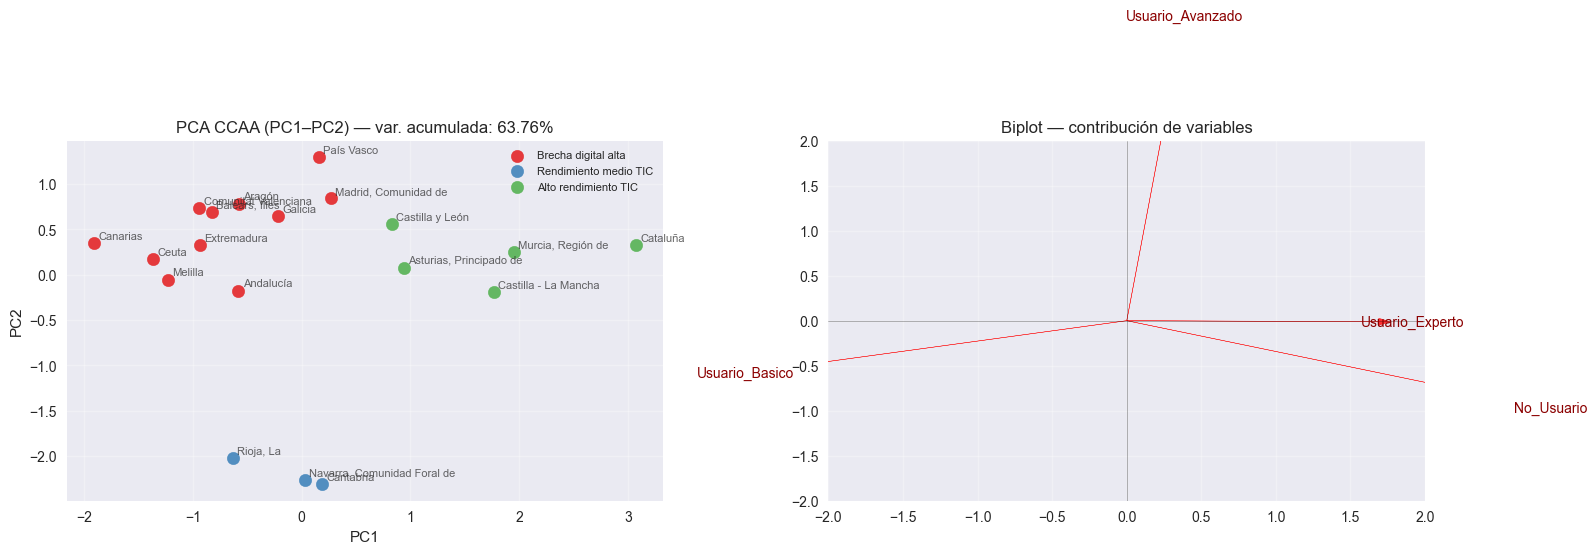

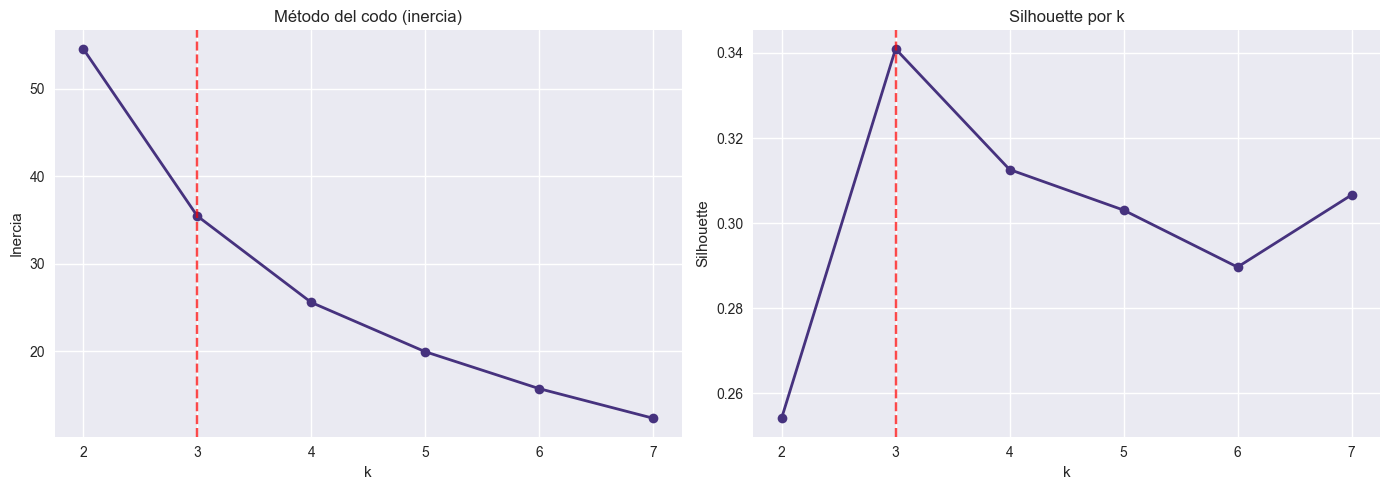

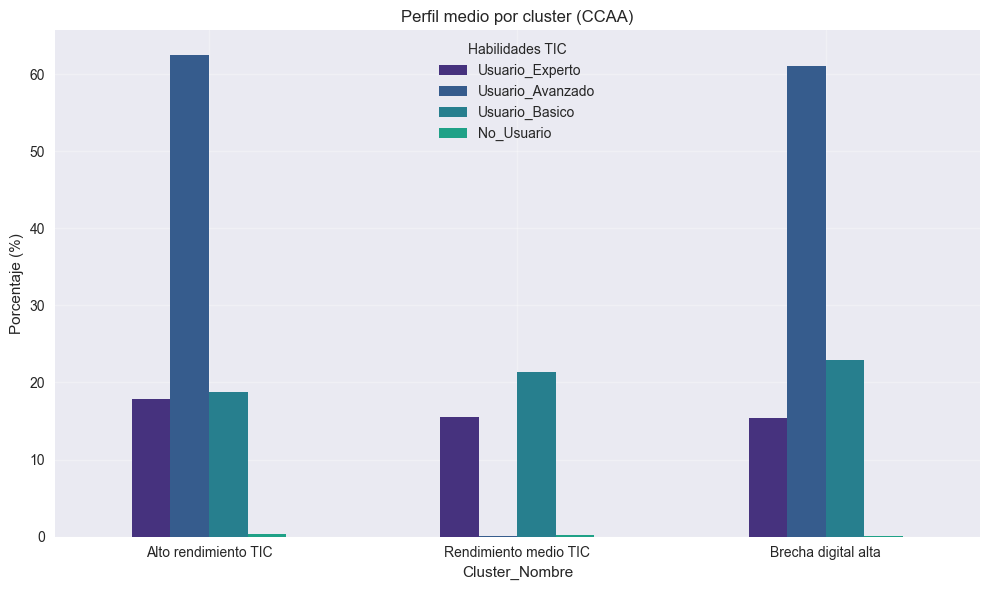

✅ Exportados:
  - Figuras: pca_biplot_ccaa.png kmeans_elbow_silhouette.png cluster_profile_bars.png en ..\reports\figures
  - CSV: ccaa_clusters.csv, pca_loadings.csv en ..\data\processed


In [28]:
# ============================================================================
# 🎯 PASO 10: ANÁLISIS MULTIVARIADO AVANZADO - PCA y CLUSTERING
# ============================================================================

"""
Aplicamos técnicas de análisis multivariado como PCA y clustering
para identificar patrones complejos y agrupar entidades similares.
"""

def analisis_multivariado(df, k_min=2, k_max=7):
    """PCA + KMeans con selección de k por silhouette, gráficos y export entregables."""
    print("\n" + "="*50)
    print("🎯 ANÁLISIS MULTIVARIADO AVANZADO")
    print("="*50)

    # Preparar datos para análisis multivariado
    df_multi = df[
        (df['Sexo'] == 'Total') &
        (df['Tipo_Centro'] == 'Total') &
        (df['CCAA'] != 'Total Nacional')
    ].copy().reset_index(drop=True)

    variables_analisis = ['Usuario_Experto_Pct', 'Usuario_Avanzado_Pct',
                          'Usuario_Basico_Pct', 'No_Usuario_Pct']

    X = df_multi[variables_analisis].to_numpy()

    # ------------------ PCA ------------------
    # 1. ANÁLISIS DE COMPONENTES PRINCIPALES (PCA)
    print("\n🔍 1. ANÁLISIS DE COMPONENTES PRINCIPALES (PCA)")
    print("-" * 50)

    # Estandarizar datos
    scaler = StandardScaler()
    X_std = scaler.fit_transform(X)
    
    # Aplicar PCA
    pca = PCA(n_components=4, random_state=42)
    X_pca = pca.fit_transform(X_std)

    # Crear DataFrame con componentes
    df_pca = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])
    df_pca['CCAA'] = df_multi['CCAA'].values  # misma longitud/orden

    print("📊 Varianza explicada por componente:")
    for i, v in enumerate(pca.explained_variance_ratio_):
        print(f"   PC{i+1}: {v:.3f} ({v*100:.1f}%)")
    print(f"📈 Varianza acumulada PC1+PC2: {pca.explained_variance_ratio_[:2].sum()*100:.1f}%")



    # ------------------ Selección de k (codo + silhouette) ------------------

    # 2. ANÁLISIS DE CLUSTERING (K-MEANS)
    print("\n🎯 2. ANÁLISIS DE CLUSTERING (K-MEANS)")
    print("-" * 45)

    # Determinar número óptimo de clusters (método del codo)
    inertias, silhouettes, modelos = [], [], {}
    k_range = range(k_min, k_max+1)
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(X_std)
        modelos[k] = km
        inertias.append(km.inertia_)
        # silhouette requiere al menos 2 clusters y < n_samples
        try:
            sil = silhouette_score(X_std, labels)
        except Exception:
            sil = np.nan
        silhouettes.append(sil)

    # Elegimos k con mejor silhouette (fallback k=3 si todo NaN)
    k_opt = (pd.Series(silhouettes, index=list(k_range)).idxmax()
             if np.isfinite(silhouettes).any() else 3)
    print(f"⚙️  k óptimo por silhouette: {k_opt}  (sil={pd.Series(silhouettes, index=list(k_range))[k_opt]:.3f})")

    kmeans_final = modelos[k_opt]
    clusters = kmeans_final.predict(X_std)


    # ------------------ Asignación de clusters ------------------
    # Añadir clusters al DataFrame
    df_multi['Cluster'] = clusters
    # Nombres “humanos” (ordenados por media de experto desc)
    orden_clusters = (df_multi.groupby('Cluster')['Usuario_Experto_Pct']
                      .mean().sort_values(ascending=False).index.tolist())
    nombre_map = {orden_clusters[0]: 'Alto rendimiento TIC'}
    if len(orden_clusters) > 1: nombre_map[orden_clusters[1]] = 'Rendimiento medio TIC'
    if len(orden_clusters) > 2: nombre_map[orden_clusters[2]] = 'Brecha digital alta'
    # relleno por si hay más clusters:
    for c in range(k_opt):
        nombre_map.setdefault(c, f'Cluster {c}')
    df_multi['Cluster_Nombre'] = df_multi['Cluster'].map(nombre_map)


    print("\n📋 CCAA por cluster:")
    for c in sorted(df_multi['Cluster'].unique()):
        ccaa_cluster = df_multi.loc[df_multi['Cluster']==c, 'CCAA'].tolist()
        print(f"  • {nombre_map[c]} (k={c}): {', '.join(ccaa_cluster)}")

    # ------------------  Visualización   ------------------
    # ------------------ Figuras y export ------------------
    fig_dir = Path("../reports/figures"); fig_dir.mkdir(parents=True, exist_ok=True)


    # (A) PCA: scatter PC1–PC2 + biplot
    # Visualizar clustering
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))


    # Scatter PC1-PC2 coloreado por cluster
    colores = ['#e41a1c','#377eb8','#4daf4a','#984ea3','#ff7f00','#a65628','#f781bf']
    for c in sorted(df_multi['Cluster'].unique()):
        mask = (df_multi['Cluster'] == c).values  # máscara posicional
        axes[0].scatter(df_pca.loc[mask, 'PC1'], df_pca.loc[mask, 'PC2'],
                        s=80, alpha=0.85, label=nombre_map[c],
                        color=colores[c % len(colores)])
    for i, name in enumerate(df_pca['CCAA']):
        axes[0].annotate(name, (df_pca.loc[i,'PC1'], df_pca.loc[i,'PC2']),
                         fontsize=8, alpha=0.7, xytext=(3,3), textcoords="offset points")
    axes[0].set_title(f"PCA CCAA (PC1–PC2) — var. acumulada: {pca.explained_variance_ratio_[:2].sum():.2%}")
    axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2"); axes[0].grid(alpha=0.3); axes[0].legend(fontsize=8)

    # Biplot (cargas)
    loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
    for i, var in enumerate(variables_analisis):
        axes[1].arrow(0, 0, loadings[i, 0]*3, loadings[i, 1]*3,
                      head_width=0.08, head_length=0.08, fc='red', ec='red', alpha=0.8)
        axes[1].text(loadings[i, 0]*3.4, loadings[i, 1]*3.4,
                     var.replace('_Pct',''), fontsize=10, ha='center', va='center', color='darkred')
    axes[1].set_xlim(-2, 2); axes[1].set_ylim(-2, 2)
    axes[1].axhline(0, color='k', lw=0.5, alpha=0.4); axes[1].axvline(0, color='k', lw=0.5, alpha=0.4)
    axes[1].set_title("Biplot — contribución de variables"); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    pca_fig = fig_dir / "pca_biplot_ccaa.png"
    plt.savefig(pca_fig, dpi=150)
    plt.show()

    # (B) Método del codo + silhouette
    fig2, ax2 = plt.subplots(1, 2, figsize=(14,5))
    ax2[0].plot(list(k_range), inertias, 'o-', lw=2)
    ax2[0].set_title("Método del codo (inercia)"); ax2[0].set_xlabel("k"); ax2[0].set_ylabel("Inercia")
    ax2[0].axvline(k_opt, color='red', ls='--', alpha=0.7)

    ax2[1].plot(list(k_range), silhouettes, 'o-', lw=2)
    ax2[1].set_title("Silhouette por k"); ax2[1].set_xlabel("k"); ax2[1].set_ylabel("Silhouette")
    ax2[1].axvline(k_opt, color='red', ls='--', alpha=0.7)
    plt.tight_layout()
    elbow_fig = fig_dir / "kmeans_elbow_silhouette.png"
    plt.savefig(elbow_fig, dpi=150)
    plt.show()

    # (C) Perfil medio por cluster (barras)
    perfiles = df_multi.groupby('Cluster_Nombre')[variables_analisis].mean().reindex(
        sorted(df_multi['Cluster_Nombre'].unique(), key=lambda n: list(nombre_map.values()).index(n))
    )
    ax3 = perfiles.rename(columns=lambda c: c.replace('_Pct','')).plot(kind='bar', figsize=(10,6))
    ax3.set_title("Perfil medio por cluster (CCAA)"); ax3.set_ylabel("Porcentaje (%)"); ax3.grid(alpha=0.3)
    plt.xticks(rotation=0); plt.tight_layout()
    prof_fig = fig_dir / "cluster_profile_bars.png"
    plt.savefig(prof_fig, dpi=150); plt.show()

    # ------------------ Export entregables ------------------
    out_dir = Path("../data/processed"); out_dir.mkdir(parents=True, exist_ok=True)
    df_clusters = df_multi[['CCAA','Cluster','Cluster_Nombre'] + variables_analisis].sort_values(['Cluster','CCAA'])
    df_clusters.to_csv(out_dir / "ccaa_clusters.csv", index=False)

    loadings_df = pd.DataFrame(loadings, index=variables_analisis, columns=['PC1','PC2','PC3','PC4'])
    loadings_df.to_csv(out_dir / "pca_loadings.csv")

    print("✅ Exportados:")
    print("  - Figuras:", pca_fig.name, elbow_fig.name, prof_fig.name, "en", fig_dir)
    print("  - CSV: ccaa_clusters.csv, pca_loadings.csv en", out_dir)
    return df_multi, df_pca, perfiles, pca, kmeans_final, k_opt

df_multivariado, df_pca_resultado, perfiles_clusters, pca_model, kmeans_model, k_optimo = analisis_multivariado(df_limpio)

**11: STORYTELLING E INSIGHTS CLAVE**
========================================================
Traducimos nuestros hallazgos estadísticos en una narrativa coherente que cuente la historia de los datos y genere insights accionables.

Consolidamos lo aprendido en el EDA:
- KPI nacionales (medias por CCAA).
- Rankings (Top/Bottom) en habilidades TIC y brecha:
    - Top 3 experto = mayor Usuario_Experto_Pct
    - Top 3 brecha = mayor Brecha_Digital_Pct
- Brechas por género y por tipo de centro (público/privado): calculadas como media agregada por CCAA (sexo/centro), consistente con el resto del notebook.
- Señales estadísticas (correlaciones y pruebas de hipótesis).
- Resumen de clusters (perfiles) del análisis multivariado.

El foco es traducir métricas en insights accionables para un público ejecutivo.


In [29]:
# ============================================================================
# 📈 PASO 11: STORYTELLING E INSIGHTS CLAVE
# ============================================================================

"""
Traducimos nuestros hallazgos estadísticos en una narrativa coherente
que cuente la historia de los datos y genere insights accionables.
"""

# --- Bootstrap para asegurar df_limpio disponible ---
import sys
from pathlib import Path
import pandas as pd

if 'df_limpio' not in globals():
    # añade src/ al PYTHONPATH por si el kernel es nuevo
    SRC = (Path.cwd().parent / "src").resolve()
    if str(SRC) not in sys.path:
        sys.path.insert(0, str(SRC))

    try:
        from eda_eso_tic.paths import CLEAN_FILE, RAW_FILE
        from eda_eso_tic.data_utils import load_raw, clean_ine_43698
    except Exception as e:
        raise RuntimeError(f"No puedo importar utilidades del paquete. ¿Ejecutaste PASO 2? -> {e}")

    clean_path = Path(CLEAN_FILE)
    if clean_path.exists():
        df_limpio = pd.read_csv(clean_path)
        print(f"✅ Cargado df_limpio desde {clean_path} -> {df_limpio.shape}")
    else:
        print("ℹ️ No existe processed; limpio a partir del RAW…")
        df_raw = load_raw(RAW_FILE)
        df_limpio = clean_ine_43698(df_raw)
        clean_path.parent.mkdir(parents=True, exist_ok=True)
        df_limpio.to_csv(clean_path, index=False)
        print(f"✅ Guardado limpio en {clean_path} -> {df_limpio.shape}")

        
def generar_storytelling_insights(df, df_multivariado=None, resultados_hipotesis=None):
    """Storytelling + insights con métricas coherentes (sin 'Total Nacional')
       y salida estructurada para el executive report."""
    print("\n" + "="*60)


    def _to_float(x):
        # Convierte a float o np.nan para evitar pd.NA en comparaciones / np.isfinite
        try:
            return np.nan if pd.isna(x) else float(x)
        except Exception:
            return np.nan
        
       
    print("📖 STORYTELLING: LA HISTORIA DE LOS DATOS")
    print("="*60)


    # ---- Ámbito base coherente con el EDA: Totales por CCAA (sin Total Nacional) ----
    # CONTEXTO Y HALLAZGOS PRINCIPALES
    print("\n🎓 EL PANORAMA EDUCATIVO TIC EN ESPAÑA")
    print("-" * 45)

    # Estadísticas generales
    scope = df[(df['Sexo'] == 'Total') & (df['Tipo_Centro'] == 'Total') & (df['CCAA'] != 'Total Nacional')].copy()
    
    # KPI nacionales (media simple de CCAA)
    promedio_experto = _to_float(scope['Usuario_Experto_Pct'].mean())
    promedio_brecha  = _to_float(scope['Brecha_Digital_Pct'].mean())
    corr_exp_brecha  = _to_float(scope['Usuario_Experto_Pct'].corr(scope['Brecha_Digital_Pct']))

    print(f"""
📊 SITUACIÓN ACTUAL:
En España, el {promedio_experto:.1f}% de los graduados en ESO alcanza nivel
**experto** en habilidades TIC, mientras que la **brecha digital**
(Básico + No usuario) es del {promedio_brecha:.1f}%.
    """)

    # ---- Brecha de género (media agregada por CCAA) ----
    # ANÁLISIS POR DIMENSIONES
    print("\n🚹🚺 LA BRECHA DE GÉNERO DIGITAL")
    print("-" * 35)

    gen = df[(df['Tipo_Centro'] == 'Total') & (df['Sexo'].isin(['Hombres', 'Mujeres'])) & (df['CCAA'] != 'Total Nacional')].copy()
    hombres_exp = _to_float(gen[gen['Sexo'] == 'Hombres']['Usuario_Experto_Pct'].mean())
    mujeres_exp = _to_float(gen[gen['Sexo'] == 'Mujeres']['Usuario_Experto_Pct'].mean())
    brecha_genero = (hombres_exp - mujeres_exp) if np.isfinite(hombres_exp) and np.isfinite(mujeres_exp) else np.nan

    if np.isfinite(brecha_genero):
        if abs(brecha_genero) > 1:
            genero_superior = "los hombres" if brecha_genero > 0 else "las mujeres"
            print(f"""
📈 HALLAZGO CLAVE:
Existe una brecha de género de {abs(brecha_genero):.1f} puntos porcentuales a favor de {genero_superior} en **usuario experto** o en habilidades TIC expertas..
Hombres: {hombres_exp:.1f}% | Mujeres: {mujeres_exp:.1f}%
            """)
        else:
            print("✅ No se detecta una brecha de género relevante a nivel agregado.")
    else:
        print("ℹ️ No hay datos suficientes para estimar brecha de género.")


    # ---- Público vs Privado (media agregada por CCAA, sexo=Total) ----
    print("\n🏫 CENTROS PÚBLICOS VS PRIVADOS")
    print("-" * 35)

    cen = df[(df['Sexo'] == 'Total') & (df['Tipo_Centro'].isin(['Públicos', 'Privados'])) & (df['CCAA'] != 'Total Nacional')].copy()
    publicos_exp = _to_float(cen[cen['Tipo_Centro'] == 'Públicos']['Usuario_Experto_Pct'].mean())
    privados_exp = _to_float(cen[cen['Tipo_Centro'] == 'Privados']['Usuario_Experto_Pct'].mean())
    brecha_centro = (privados_exp - publicos_exp) if np.isfinite(privados_exp) and np.isfinite(publicos_exp) else np.nan

    if np.isfinite(brecha_centro):
        if abs(brecha_centro) > 2:
            centro_superior = "privados" if brecha_centro > 0 else "públicos"
            print(f"""
🎯 INSIGHT EDUCATIVO:
Los centros **{centro_superior}** superan en {abs(brecha_centro):.1f} puntos
porcentuales en formación de usuarios expertos TIC.
Públicos: {publicos_exp:.1f}% | Privados: {privados_exp:.1f}%
            """)
        else:
            print("⚖️ Los centros públicos y privados muestran niveles de experto similares en promedio.")


    
    # ---- Mapa territorial: Top experto y Top brecha ----          
    print("\n🗺️ EL MAPA TERRITORIAL DE LA COMPETENCIA DIGITAL")
    print("-" * 50)

    # Top y bottom territorial
    df_territorial = df[(df['Sexo'] == 'Total') &
                       (df['Tipo_Centro'] == 'Total') &
                       (df['CCAA'] != 'Total Nacional')]

    top_3_experto = scope.nlargest(3, 'Usuario_Experto_Pct')
    top_3_brecha  = scope.nlargest(3, 'Brecha_Digital_Pct')

    print("🏆 COMUNIDADES LÍDERES (Usuario experto):")
    for i, (_, row) in enumerate(top_3_experto.iterrows(), 1):
        print(f"   {i}. {row['CCAA']}: {row['Usuario_Experto_Pct']:.1f}%")

    print("\n📉 MAYOR BRECHA DIGITAL (Básico + No usuario):")
    for i, (_, row) in enumerate(top_3_brecha.iterrows(), 1):
        print(f"   {i}. {row['CCAA']}: {row['Brecha_Digital_Pct']:.1f}%")

    # Rangos territoriales completos (max − min)
    rango_experto = _to_float(scope['Usuario_Experto_Pct'].max() - scope['Usuario_Experto_Pct'].min())
    rango_brecha  = _to_float(scope['Brecha_Digital_Pct'].max() - scope['Brecha_Digital_Pct'].min())

    # ---- Clustering (si viene del PASO 10) ----
    # Análisis de clustering
    print("\n🎯 TIPOLOGÍA DE CCAA (clusters)")
    print("-" * 40)
    clusters_resumen = ""
    if df_multivariado is not None and 'Cluster_Nombre' in df_multivariado.columns:
        for cluster_nombre in df_multivariado['Cluster_Nombre'].unique():
            ccaa_cluster = df_multivariado[df_multivariado['Cluster_Nombre'] == cluster_nombre]
            ux = _to_float(ccaa_cluster['Usuario_Experto_Pct'].mean())
            bd = _to_float(ccaa_cluster['Brecha_Digital_Pct'].mean())
            print(f"\n📊 {cluster_nombre}:")
            print(f"   Comunidades: {', '.join(ccaa_cluster['CCAA'].tolist())}")
            print(f"   Usuario experto prom.: {ux:.1f}%")
            print(f"   Brecha digital prom.:  {bd:.1f}%")
        sizes = df_multivariado['Cluster_Nombre'].value_counts().to_dict()
        clusters_resumen = "\n".join([f"- {k}: {v} CCAA" for k, v in sizes.items()])
    else:
        print("ℹ️ Ejecuta el PASO 10 para obtener clusters y perfiles.")

    

    # ---- Señales de significación (si viene del PASO 7) ----
    badges = []
    if isinstance(resultados_hipotesis, dict):
        gp = resultados_hipotesis.get("genero_pvalue")
        cp = resultados_hipotesis.get("centro_pvalue")
        xp = resultados_hipotesis.get("ccaa_pvalue")
        if gp is not None:
            badges.append("✓ Género significativo (t-test)" if gp < 0.05 else "× Género NO significativo")
        if cp is not None:
            badges.append("✓ Público–Privado significativo (t-test)" if cp < 0.05 else "× Público–Privado NO significativo")
        if xp is not None:
            badges.append("✓ Asociación CCAA–Nivel TIC (chi²)" if xp < 0.05 else "× Sin asociación CCAA–Nivel TIC (chi²)")
        if badges:
            print("\n🧪 Pruebas de hipótesis:", " | ".join(badges))


    # IMPLICACIONES Y RECOMENDACIONES
    print("\n" + "="*60)
    print("💡 INSIGHTS ESTRATÉGICOS Y RECOMENDACIONES")
    print("="*60)

    insights_estrategicos = []

    # Insight 1: Brecha digital generalizada
    if promedio_experto < 30:
        insights_estrategicos.append(
            f"🚨 CRISIS DE COMPETENCIA DIGITAL: Sólo {promedio_experto:.1f}% de graduados "
            f"alcanza nivel experto. España necesita una revolución educativa TIC."
        )

    # Insight 2: Desigualdades territoriales
    if (np.isfinite(rango_experto) and rango_experto > 10) or (np.isfinite(rango_brecha) and rango_brecha > 10):
        insights_estrategicos.append(
            f"🗺️ ESPAÑA DE DOS VELOCIDADES: Diferencia territoriales relevantes — "
            f"entre la mejor y peor CCAA indica desigualdades territoriales críticas."
            f"Rango en % experto {rango_experto:.1f} pp y rango en brecha {rango_brecha:.1f} porcentual."
        )

    # Insight 3: Efectividad de centros privados
    if np.isfinite(brecha_centro) and brecha_centro > 3:
        insights_estrategicos.append(
            f"🏫 BRECHA PÚBLICO-PRIVADA: Los centros privados aventajan por "
            f"{brecha_centro:.1f} puntos porcentuales, sugiriendo necesidad de inversión pública en TIC."
        )

    # Insight 4: Brecha de género
    if np.isfinite(brecha_genero) and abs(brecha_genero) > 2:
        femmes = "mujeres" if brecha_genero < 0 else "hombres"
        insights_estrategicos.append(
            f"⚖️ BRECHA DE GÉNERO: Las {femmes} están {abs(brecha_genero):.1f} puntos porcentuales "
            f"por debajo, requiriendo programas específicos de inclusión digital indicando una brecha de género significativa."
        )

    print("\n🎯 INSIGHTS CLAVE:")
    for i, insight in enumerate(insights_estrategicos, 1):
        print(f"\n{i}. {insight}")

    # RECOMENDACIONES ESTRATÉGICAS
    recomendaciones = [
        "💰 INVERSIÓN PRIORITARIA: Incrementar y acelerar el presupuesto TIC educativo (infraestructura + contenidos).",
        "🎯 PROGRAMAS FOCALIZADOS: Intervenciones específicas en CCAA con mayor brecha (programas intensivos).",
        "👥 FORMACIÓN DOCENTE: Plan nacional de capacitación TIC docente en competencias digitales.",
        "📱 INFRAESTRUCTURA DIGITAL: Garantizar conectividad y dispositivos en todos los centros, priorizando aquellos centros con desventaja.",
        "🔍 MONITOREO CONTINUO: Seguimiento continuo con KPIs y panel de control (dashboard) público de competencias TIC"
    ]

    if np.isfinite(brecha_genero) and abs(brecha_genero) > 2:
        recomendaciones.append("⚖️ IGUALDAD DE GÉNERO: Programas específicos de inclusión digital por género para cerrar brecha digital de género")

      
    print(f"\n📋 RECOMENDACIONES ESTRATÉGICAS:")
    for i, recomendacion in enumerate(recomendaciones, 1):
        print(f"\n{i}. {recomendacion}")

    # --- Devolver también en formato estructurado para el PASO 12 ---
    return {
        "kpis": {
            "experto": promedio_experto,
            "brecha":  promedio_brecha,
            "corr_exp_brecha": corr_exp_brecha
        },
        "hombres_exp": hombres_exp,
        "mujeres_exp": mujeres_exp,
        "brecha_genero": brecha_genero,
        "publicos_exp": publicos_exp,
        "privados_exp": privados_exp,
        "brecha_centro": brecha_centro,
        "top_3_experto": top_3_experto[['CCAA','Usuario_Experto_Pct']],
        "top_3_brecha":  top_3_brecha[['CCAA','Brecha_Digital_Pct']],
        "rango_experto": rango_experto,
        "rango_brecha":  rango_brecha,
        "clusters_resumen": clusters_resumen,
        "badges": badges if badges else [],
        "insights": insights_estrategicos,
        "recomendaciones": recomendaciones
    }

# ---- Ejecutar y capturar payload estructurado ----
story_payload = generar_storytelling_insights(
    df_limpio,
    df_multivariado if 'df_multivariado' in globals() else None,
    resultados_hipotesis if 'resultados_hipotesis' in globals() else None
)



📖 STORYTELLING: LA HISTORIA DE LOS DATOS

🎓 EL PANORAMA EDUCATIVO TIC EN ESPAÑA
---------------------------------------------

📊 SITUACIÓN ACTUAL:
En España, el 16.1% de los graduados en ESO alcanza nivel
**experto** en habilidades TIC, mientras que la **brecha digital**
(Básico + No usuario) es del 21.8%.
    

🚹🚺 LA BRECHA DE GÉNERO DIGITAL
-----------------------------------

📈 HALLAZGO CLAVE:
Existe una brecha de género de 12.7 puntos porcentuales a favor de los hombres en **usuario experto** o en habilidades TIC expertas..
Hombres: 20.9% | Mujeres: 8.1%
            

🏫 CENTROS PÚBLICOS VS PRIVADOS
-----------------------------------

🗺️ EL MAPA TERRITORIAL DE LA COMPETENCIA DIGITAL
--------------------------------------------------
🏆 COMUNIDADES LÍDERES (Usuario experto):
   1. Castilla - La Mancha: 20.5%
   2. Cataluña: 20.1%
   3. Rioja, La: 18.6%

📉 MAYOR BRECHA DIGITAL (Básico + No usuario):
   1. Melilla: 28.2%
   2. Andalucía: 27.4%
   3. Ceuta: 27.4%

🎯 TIPOLOGÍA DE CCAA (

**12: INFORME FINAL**
========================================================
Generamos un informe ejecutivo completo que sintetiza todos nuestros hallazgos en un formato profesional para presentar a un posible CEO.

### Nota:
- El PDF se crea con **ReportLab** y se guarda en: `reports/executive_report.pdf`.
- Si `reportlab` no está instalado, la celda intentará **instalarlo automáticamente**.
- El README se regenera con el enlace al **PDF** y al **Markdown** del informe.

In [30]:
# ============================================================================
# 📊 PASO 12: INFORME EJECUTIVO FINAL
# ============================================================================

"""
Generamos un informe ejecutivo completo que sintetiza todos nuestros
hallazgos en un formato profesional para presentar a un posible CEO.
"""


# --- imports reportlab / notebook link
# --- PDF (ReportLab)
from reportlab.lib.pagesizes import A4
from reportlab.platypus import (BaseDocTemplate, Frame, PageTemplate, Paragraph,
                                Spacer, Image, Table, TableStyle, PageBreak, KeepTogether)
from reportlab.platypus.tableofcontents import TableOfContents
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib import colors
from reportlab.lib.utils import ImageReader

from IPython.display import FileLink, display
FileLink("reports/executive_report.pdf")


# ----------------------------------------------------------
# Utilidades comunes previas (reusamos story_payload/df) del PASO 11
# -----------------------------------------------------------

def _exists(p): 
    try: 
        return Path(p).exists()
    except Exception: 
        return False

def _ensure_reportlab():
    try:
        import reportlab  # noqa
        return True
    except Exception:
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "reportlab"])
            return True
        except Exception as e:
            print("⚠️ No se pudo instalar reportlab automáticamente:", e)
            return False
        
def _scaled_image(path, doc, max_w=None, max_h=None):
    if max_w is None: max_w = doc.width
    if max_h is None: max_h = doc.height * 0.55
    ir = ImageReader(path)
    iw, ih = ir.getSize()
    sw = max_w/float(iw); sh = max_h/float(ih)
    s = min(sw, sh, 1.0)
    w, h = iw*s, ih*s
    img = Image(path, width=w, height=h); img.hAlign = "LEFT"
    return img


def _md_table(df: pd.DataFrame) -> str:
    try:
        return df.to_markdown(index=False)
    except Exception:
        return df.to_string(index=False)


# ------------------ Resumenes analíticos (para comentarios bajo figuras) ------------------
def _resumen_pca(df_scope: pd.DataFrame) -> dict:
    try:
        from sklearn.preprocessing import StandardScaler
        from sklearn.decomposition import PCA
        vars_ = ['Usuario_Experto_Pct','Usuario_Avanzado_Pct','Usuario_Basico_Pct','No_Usuario_Pct']
        X = df_scope[vars_].to_numpy()
        X = StandardScaler().fit_transform(X)
        pca = PCA().fit(X)
        evr = pca.explained_variance_ratio_
        return {
            "pc1": float(evr[0]*100),
            "pc2": float(evr[1]*100),
            "cum12": float((evr[0]+evr[1])*100)
        }
    except Exception:
        return {"pc1": np.nan, "pc2": np.nan, "cum12": np.nan}

def _resumen_clusters(df_scope: pd.DataFrame, df_multivariado=None) -> dict:
    # Si ya ejecutasmos el PASO 10, usamos df_multivariado; si no, lo inferimos rápido (k=3)
    try:
        if df_multivariado is not None and "Cluster_Nombre" in df_multivariado.columns:
            counts = df_multivariado["Cluster_Nombre"].value_counts().to_dict()
            perfiles = (df_multivariado
                        .groupby("Cluster_Nombre")[["Usuario_Experto_Pct","Brecha_Digital_Pct"]]
                        .mean().round(1))
            perf_txt = "; ".join([f"{k}: Exp {perfiles.loc[k,'Usuario_Experto_Pct']}% · Brecha {perfiles.loc[k,'Brecha_Digital_Pct']}%"
                                  for k in perfiles.index])
            return {"counts": counts, "perfil": perf_txt}
        else:
            from sklearn.preprocessing import StandardScaler
            from sklearn.cluster import KMeans
            vars_ = ['Usuario_Experto_Pct','Usuario_Avanzado_Pct','Usuario_Basico_Pct','No_Usuario_Pct']
            X = StandardScaler().fit_transform(df_scope[vars_].to_numpy())
            km = KMeans(n_clusters=3, random_state=42, n_init=10).fit(X)
            df_tmp = df_scope.copy()
            df_tmp["Cluster"] = km.labels_
            perfiles = (df_tmp
                        .groupby("Cluster")[["Usuario_Experto_Pct","Brecha_Digital_Pct"]]
                        .mean().round(1))
            counts = df_tmp["Cluster"].value_counts().sort_index().to_dict()
            perf_txt = "; ".join([f"C{c}: Exp {perfiles.loc[c,'Usuario_Experto_Pct']}% · Brecha {perfiles.loc[c,'Brecha_Digital_Pct']}%"
                                  for c in perfiles.index])
            return {"counts": counts, "perfil": perf_txt}
    except Exception:
        pass
    return {"counts": {}, "perfil": ""}
        
# --------------------------------------------------
# 12. A - Genera Informe MD/TXT 
# --------------------------------------------------

def generar_informe_md_txt(df: pd.DataFrame,
                           story: dict | None = None,
                           resultados_hipotesis: dict | None = None,
                           out_dir="../reports",
                           fname_base="executive_report"):
    out_dir = Path(out_dir); out_dir.mkdir(parents=True, exist_ok=True)
    scope = df[(df["Sexo"]=="Total") & (df["Tipo_Centro"]=="Total") & (df["CCAA"]!="Total Nacional")].copy()

    if story is None or not isinstance(story, dict):
        story = {}
    k = story.setdefault("kpis", {})
    k.setdefault("experto", scope["Usuario_Experto_Pct"].mean())
    k.setdefault("brecha",  scope["Brecha_Digital_Pct"].mean())
    k.setdefault("corr_exp_brecha", scope["Usuario_Experto_Pct"].corr(scope["Brecha_Digital_Pct"]))

    # estilos MD compactos
    fecha = datetime.now().strftime("%d/%m/%Y")
    md = f"""# Informe Ejecutivo — Graduados ESO · Habilidades TIC (INE · 43698)

**Fecha:** {fecha}  
**Ámbito:** Totales por CCAA (Sexo=Total, Tipo=Total)  

Este informe resume la calidad de datos, limpieza aplicada, hallazgos del EDA (univariado, bivariado y multivariado), contrastes de hipótesis, mapas y recomendaciones.
"""
    (out_dir/f"{fname_base}.md").write_text(md, encoding="utf-8")
    (out_dir/f"{fname_base}.txt").write_text(md.replace("#",""), encoding="utf-8")
    return {"story": story}

def generar_pdf_con_indice_y_resumen(df: pd.DataFrame,
                                     story: dict,
                                     group_info: dict,
                                     resultados_hipotesis: dict | None = None,
                                     out_dir="../reports",
                                     pdf_name="executive_report.pdf"):
    if not _ensure_reportlab():
        print("❌ ReportLab no disponible: omito PDF."); return None

    out_dir = Path(out_dir); out_dir.mkdir(parents=True, exist_ok=True)
    pdf_path = out_dir / pdf_name

    # -------- estilos
    styles = getSampleStyleSheet()
    styles.add(ParagraphStyle(name="H1", parent=styles["Heading1"], fontSize=16, spaceAfter=8))
    styles.add(ParagraphStyle(name="H2", parent=styles["Heading2"], fontSize=13, spaceAfter=6))
    styles.add(ParagraphStyle(name="Body", parent=styles["BodyText"], fontSize=10, leading=14))
    styles.add(ParagraphStyle(name="Small", parent=styles["BodyText"], fontSize=9, leading=12, textColor=colors.grey))

    project_name = "EDA · Graduados ESO — Habilidades TIC (INE·43698)"
    group_name   = group_info.get("grupo","Equipo de Análisis")
    institucion  = group_info.get("institucion","")
    version      = group_info.get("version","")
    miembros     = group_info.get("miembros",[])
    logo_path    = group_info.get("logo_path")

    # sin cabecera que pisa títulos
    def _blank_header(canvas, doc): pass
    def _footer(canvas, doc):
        canvas.saveState()
        canvas.setFont("Helvetica", 9)
        canvas.setFillColor(colors.HexColor("#444"))
        left = f"{group_name}" + (f" · {institucion}" if institucion else "") + (f" · {version}" if version else "")
        canvas.drawString(doc.leftMargin, doc.bottomMargin - 18, left)
        canvas.drawRightString(doc.leftMargin + doc.width, doc.bottomMargin - 18, f"Página {doc.page}")
        canvas.restoreState()

    class MyDoc(BaseDocTemplate):
        def __init__(self, filename, **kw):
            super().__init__(filename, **kw)
            frame = Frame(self.leftMargin, self.bottomMargin, self.width, self.height, id="normal")
            self.addPageTemplates([PageTemplate(id="main", frames=frame, onPage=_blank_header, onPageEnd=_footer)])
        def afterFlowable(self, flowable):
            if isinstance(flowable, Paragraph) and flowable.style.name in ("H1","H2"):
                level = 0 if flowable.style.name=="H1" else 1
                self.notify("TOCEntry", (level, flowable.getPlainText(), self.page))

    doc = MyDoc(str(pdf_path), pagesize=A4, leftMargin=36, rightMargin=36, topMargin=42, bottomMargin=42)
    E = []

    # ---- Portada
    E += [Spacer(1, 40),
          Paragraph("Informe Ejecutivo", styles["H1"]),
          Paragraph("Graduados en ESO — Habilidades TIC por sexo, CCAA y tipo de centro", styles["Body"]),
          Paragraph("(INE · API 43698)", styles["Small"]),
          Spacer(1, 16)]
    if logo_path and _exists(logo_path):
        try: E += [Image(logo_path, width=160, height=None), Spacer(1,10)]
        except: pass
    meta = [f"<b>Grupo:</b> {group_name}",
            f"<b>Miembros:</b> {', '.join(miembros) if miembros else '—'}",
            (f"<b>Institución:</b> {institucion}" if institucion else ""),
            f"<b>Fecha:</b> {datetime.now().strftime('%d/%m/%Y')}",
            (f"<b>Versión:</b> {version}" if version else "")]
    for line in meta:
        if line: E.append(Paragraph(line, styles["Body"]))
    E.append(PageBreak())

    # ---- Índice
    E.append(Paragraph("Índice", styles["H1"]))
    toc = TableOfContents()
    toc.levelStyles = [
        ParagraphStyle(name="TOC1", fontSize=11, leftIndent=0, firstLineIndent=-10, spaceBefore=4, leading=14),
        ParagraphStyle(name="TOC2", fontSize=10, leftIndent=12, firstLineIndent=-10, spaceBefore=2, leading=12),
    ]
    E += [toc, PageBreak()]

    # ---- Calidad de datos y limpieza (comentada)
    E.append(Paragraph("Calidad de datos y limpieza", styles["H1"]))
    scope = df[(df["Sexo"]=="Total") & (df["Tipo_Centro"]=="Total") & (df["CCAA"]!="Total Nacional")]
    compl = ((1 - df.isnull().sum()/len(df))*100).mean()
    E.append(Paragraph(
        "Se partió del CSV oficial del INE. Se aplicaron: "
        "1) normalización y recodificación de categorías; "
        "2) exclusión de ‘Total Nacional’ para evitar doble conteo; "
        "3) validación de porcentajes (0–100) y consistencia (≈100% por fila tras pivoteo); "
        "4) tratamiento de ausentes (mediana) donde procedía; "
        "5) detección de outliers con IQR (no se eliminaron salvo que afectaran porcentajes imposibles).", styles["Body"]))
    E.append(Paragraph(f"Completitud media: {compl:.1f}%. Registros: {len(df):,}. Variables: {len(df.columns)}.", styles["Small"]))
    E.append(PageBreak())

    # ---- KPIs / resumen ejecutivo breve
    k = story.get("kpis", {})
    experto = float(k.get("experto", scope["Usuario_Experto_Pct"].mean()))
    brecha  = float(k.get("brecha",  scope["Brecha_Digital_Pct"].mean()))
    corr    = float(k.get("corr_exp_brecha", scope["Usuario_Experto_Pct"].corr(scope["Brecha_Digital_Pct"])))
    E.append(Paragraph("Resumen ejecutivo (KPIs)", styles["H1"]))
    E.append(Paragraph(
        f"Usuario experto medio: <b>{experto:.1f}%</b>. "
        f"Brecha digital media: <b>{brecha:.1f}%</b>. "
        f"Correlación experto↔brecha: <b>{corr:+.2f}</b> (tendencia esperada negativa).", styles["Body"]))
    E.append(PageBreak())

    # ---- EDA Univariado (con figuras)
    figs = {
        "uni_hist_experto.png": "Distribución del % de usuario experto por CCAA. Útil para ver sesgos/asimetrías y detectar colas.",
        "uni_box_brecha.png": "Boxplot de Brecha digital (Básico+No usuario). Outliers sugieren CCAA con necesidades específicas."
    }
    E.append(Paragraph("Análisis univariado", styles["H1"]))
    for fname, caption in figs.items():
        fpath = Path("../reports/figures")/fname
        if _exists(fpath):
            E.append(_scaled_image(str(fpath), doc))
            E.append(Paragraph(caption, styles["Small"]))
            E.append(Spacer(1,8))
    E.append(PageBreak())

    # ---- EDA Bivariado (correlaciones, scatter, sexo/centro)
    E.append(Paragraph("Análisis bivariado", styles["H1"]))
    bi_figs = {
        "bi_heatmap_corr.png": "Matriz de correlaciones entre niveles TIC: se observa relación negativa Experto vs Brecha.",
        "bi_scatter_experto_brecha.png": "Dispersión Experto vs Brecha con recta de tendencia: más experto, menos brecha.",
        "bi_barras_sexo.png": "Medias por sexo: diferencia esperable H vs M; confirmar con t-test.",
        "bi_barras_centro.png": "Medias por tipo de centro: privados suelen superar a públicos; ver magnitud."
    }
    for fname, caption in bi_figs.items():
        fpath = Path("../reports/figures")/fname
        if _exists(fpath):
            E.append(_scaled_image(str(fpath), doc))
            E.append(Paragraph(caption, styles["Small"]))
            E.append(Spacer(1,8))
    E.append(PageBreak())

    # ---- Multivariado (PCA y KMeans) – usa tus PNG del PASO 10 si existen
    E.append(Paragraph("Análisis multivariado (PCA + KMeans)", styles["H1"]))
    for f in ["pca_biplot_ccaa.png","cluster_profile_bars.png","kmeans_elbow_silhouette.png"]:
        fpath = Path("../reports/figures")/f
        if _exists(fpath):
            E.append(_scaled_image(str(fpath), doc))
            if f=="pca_biplot_ccaa.png":
                E.append(Paragraph("Biplot PCA: direcciones de máxima varianza; ayuda a ver ejes experto/brecha.", styles["Small"]))
            elif f=="cluster_profile_bars.png":
                E.append(Paragraph("Perfiles de clúster: alto rendimiento, medio, brecha alta.", styles["Small"]))
            elif f=="kmeans_elbow_silhouette.png":
                E.append(Paragraph("Criterios de k (codo/silueta). Se seleccionó k=3 por equilibrio interpretabilidad/separación.", styles["Small"]))
            E.append(Spacer(1,8))
    E.append(PageBreak())

    # ---- Pruebas de hipótesis
    E.append(Paragraph("Pruebas de hipótesis", styles["H1"]))
    if resultados_hipotesis:
        gp = resultados_hipotesis.get("genero_pvalue")
        cp = resultados_hipotesis.get("centro_pvalue")
        xp = resultados_hipotesis.get("ccaa_pvalue")
        lines = []
        if gp is not None: lines.append(("✓" if gp < 0.05 else "×")+f" t-test género (p={gp:.3f})")
        if cp is not None: lines.append(("✓" if cp < 0.05 else "×")+f" t-test público–privado (p={cp:.3f})")
        if xp is not None: lines.append(("✓" if xp < 0.05 else "×")+f" χ² CCAA–nivel TIC (p={xp:.3f})")
        E.append(Paragraph(" · ".join(lines) if lines else "—", styles["Body"]))
    else:
        E.append(Paragraph("—", styles["Body"]))
    E.append(PageBreak())

    # ---- Mapas y dashboards interactivos (enlaces)
    E.append(Paragraph("Mapas y dashboards (enlaces)", styles["H1"]))
    links = []
    for m in ["../reports/maps/mapa_tic_experto_ccaa.html", "../reports/maps/mapa_espana_habilidades_tic.html"]:
        if _exists(m): links.append(m)
    E.append(Paragraph("Mapas Folium: " + (" | ".join(links) if links else "— Ejecuta PASO 8"), styles["Body"]))
    dsh = Path("../reports/plotly/dashboard_habilidades_tic.html")
    E.append(Paragraph("Dashboard Plotly: " + (str(dsh) if _exists(dsh) else "— Ejecuta PASO 9"), styles["Body"]))
    E.append(PageBreak())

    # ---- Conclusiones y recomendaciones
    E.append(Paragraph("Conclusiones y recomendaciones", styles["H1"]))
    E.append(Paragraph(
        "• La competencia experta es aún moderada; urge acelerar políticas TIC educativas. "
        "• Existen desigualdades territoriales claras; priorizar CCAA con mayor brecha. "
        "• Diferencias público–privado y de género requieren intervenciones específicas.", styles["Body"]))
    E.append(Spacer(1,6))
    E.append(Paragraph("Próximos pasos: 1) Presentación a stakeholders; 2) Plan detallado; 3) Sistema de monitoreo; 4) Evaluación en 12 meses.", styles["Body"]))
    E.append(Spacer(1,6))
    E.append(Paragraph(f"Fuente: INE (API 43698) · Fecha: {datetime.now().strftime('%d/%m/%Y')}", styles["Small"]))

    # multiBuild para que funcione el TOC
    doc.multiBuild(E)
    print("✅ PDF:", pdf_path.resolve())
    return pdf_path


# --------------------------------------------------
# 12.C — README 
# --------------------------------------------------

def generar_readme_con_pdf(out_path="../README.md"):
    Path(out_path).parent.mkdir(parents=True, exist_ok=True)
    content = f"""# eda_graduados_eso_tic

EDA de **Graduados en ESO según habilidades TIC** (INE · API 43698).

## Entregables
- **Informe ejecutivo (Markdown):** `reports/executive_report.md`
- **Informe ejecutivo (PDF con portada + índice + comentarios):** `reports/executive_report.pdf`
- **Mapas:** `reports/maps/`
- **Figuras:** `reports/figures/`
- **Dashboards:** `reports/plotly/`

> Abre el PDF aquí: [reports/executive_report.pdf](reports/executive_report.pdf)
"""
    Path(out_path).write_text(content, encoding="utf-8")
    print(f"✅ README actualizado en: {Path(out_path).resolve()}")


# --------------------------------------------------
#  Ejecución PASO 12 
# --------------------------------------------------

# Bootstrap: si el kernel se reinició
if 'df_limpio' not in globals():
    # ajustado a ruta relativa desde el notebook en notebooks/
    df_limpio = pd.read_csv("../data/processed/ine_43698_clean.csv")

# 1) MD/TXT en ../reports (con narrativa adaptada)
res12 = generar_informe_md_txt(df_limpio,
                               story_payload if 'story_payload' in globals() else None,
                               resultados_hipotesis if 'resultados_hipotesis' in globals() else None)


# 2) Datos de portada PDF
group_info = {
    "grupo": "Brecha Digital Educativa — Grupo 1",
    "miembros": ["Alfonso Bermúdez Torres"],
    "institucion": "Centro/Universidad",
    "version": "v1.2",
    "logo_path": "../assets/FactoriaF5_img.png"   # opcional
}

# 3) PDF (con índice y comentarios bajo figuras)
# Asegurar de haber ejecutado la celda 6.1 "guardar_figuras_para_pdf" antes
pdf_path = generar_pdf_con_indice_y_resumen(
    df_limpio,
    res12.get("story", {}),
    group_info=group_info,
    resultados_hipotesis=(resultados_hipotesis if 'resultados_hipotesis' in globals() else None),
    out_dir="../reports",
    pdf_name="executive_report.pdf"
)

# 4) README con enlace al PDF
WRITE_README = False  # <- déjalo en False para no tocar README

if WRITE_README:
    generar_readme_con_pdf()
else:
    print("ℹ️ README no modificado (WRITE_README=False)")

# 5) Enlaces clicables desde el notebook
if pdf_path and _exists(pdf_path):
    display(FileLink(str(pdf_path)))
display(FileLink("../reports/executive_report.md"))

print("\n" + "="*70)
print("✅ PASO 12 listo — MD/TXT/PDF en ../reports (índice correcto, sin cabecera invasiva, figuras comentadas)")
print("="*70)




################################################333



✅ PDF: C:\dev\proyectos\eda_graduados_eso_tic\reports\executive_report.pdf
ℹ️ README no modificado (WRITE_README=False)


c:\dev\proyectos\eda_graduados_eso_tic\reports\executive_report.pdf

c:\dev\proyectos\eda_graduados_eso_tic\reports\executive_report.md


✅ PASO 12 listo — MD/TXT/PDF en ../reports (índice correcto, sin cabecera invasiva, figuras comentadas)
